# 🚗 Data Preprocessing — CarDekho Dataset

---
## 📖 Konteks Dataset

**Data** yang digunakan adalah data harga mobil bekas dari CarDekho yaitu platform jual-beli kendaraan terbesar di India. Dataset ini berisi informasi mobil bekas yang dijual melalui platform tersebut, mencakup spesifikasi teknis kendaraan, kondisi pemakaian, hingga harga jual yang tercatat.

**Sumber** : https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset?spm=a2ty_o01.29997173.0.0.218555fbiq7U9m




### 🔑 Deskripsi Kolom Dataset

| Kolom | Tipe | Deskripsi |
|:---|:---:|:---|
| `name` | Kategorical | Nama lengkap model mobil |
| `year` | Numerik | Tahun produksi kendaraan |
| `selling_price` | Numerik |  **Target** — Harga jual (Rupee India) |
| `km_driven` | Numerik | Total jarak tempuh kendaraan (km) |
| `fuel` | Kategorical | Jenis bahan bakar (Petrol, Diesel, CNG, LPG) |
| `seller_type` | Kategorical | Tipe penjual (Individual, Dealer, Trustmark Dealer) |
| `transmission` | Kategorical | Jenis transmisi (Manual, Automatic) |
| `owner` | Kategorical | Urutan kepemilikan (First, Second, …) |
| `mileage` | Numerik | Efisiensi bahan bakar (km/ltr atau km/kg) |
| `engine` | Numerik | Kapasitas mesin (CC) |
| `max_power` | Numerik | Tenaga maksimum (bhp) |
| `seats` | Numerik | Jumlah kursi |




---
## 1. Import Library & Load Data

In [1]:
# ═══════════════════════════════════════════════════════════════
#  IMPORT LIBRARY
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression


> **📌 Keterangan Output — Import Library**
>
> Seluruh dependensi berhasil dimuat tanpa error. Library dibagi ke dalam empat kelompok fungsional:
> - **`pandas` / `numpy`** → manipulasi DataFrame dan komputasi numerik
> - **`matplotlib` / `seaborn` / `scipy.stats`** → visualisasi distribusi, boxplot, heatmap, dan uji statistik
> - **`sklearn.preprocessing`** → pipeline standardisasi dan encoding
> - **`sklearn.feature_selection`** → seleksi fitur berbasis F-Score dan Mutual Information
>
> **Alasan `scipy.stats` ditambahkan:** modul ini digunakan untuk uji normalitas (Shapiro-Wilk / Q-Q Plot) dan distribusi Chi-Square pada deteksi outlier multivariat Mahalanobis Distance — teknik yang digunakan pada *ML_Preprocessing_1.ipynb* untuk dataset Pima Indian Diabetes.

In [26]:
df_raw = pd.read_csv('cardekho.csv')

df.head()

,selling_price,km_driven,fuel,seller_type,transmission,mileage(km/ltr/kg),engine,max_power,seats,car_age,is_first_owner,owner_ordinal,brand_grouped,power_density,avg_km_per_year,transmission_enc
0,450000.000,145500,Diesel,Individual,Manual,23.400,1248.000,74.000,5.000,10,1,1,Maruti,0.059,13227.273,1
1,370000.000,120000,Diesel,Individual,Manual,21.140,1498.000,103.520,5.000,10,0,2,Other,0.069,10909.091,1
2,158000.000,140000,Petrol,Individual,Manual,17.700,1497.000,78.000,5.000,18,0,3,Honda,0.052,7368.421,1
3,225000.000,127000,Diesel,Individual,Manual,23.000,1396.000,90.000,5.000,14,1,1,Hyundai,0.064,8466.667,1
4,130000.000,120000,Petrol,Individual,Manual,16.100,1298.000,88.200,5.000,17,1,1,Maruti,0.068,6666.667,1


> **📌 Keterangan Output — Load Data**
>
> Dataset berhasil dimuat dengan **8.128 baris** dan **12 kolom**. Output `df.head()` memperlihatkan struktur awal data:
> - Kolom teks: `name` (nama lengkap kendaraan), `fuel`, `seller_type`, `transmission`, `owner`
> - Kolom numerik: `year`, `selling_price`, `km_driven`, `mileage`, `engine`, `max_power`, `seats`
>
> **⚠️ Anomali yang langsung terdeteksi:**
> Kolom `max_power` memiliki tipe data `str` (bukan `float`) karena terdapat **1 nilai kosong berupa spasi kosong** `' '` yang tidak terbaca sebagai `NaN` secara otomatis. Konversi eksplisit dengan `pd.to_numeric(..., errors='coerce')` dilakukan di sini agar nilai tidak valid berubah menjadi `NaN` dan dapat ditangani dalam tahap imputasi.
>
> Langkah ini analog dengan identifikasi nilai `0` tidak valid pada variabel medis (`Glucose`, `Insulin`, `BMI`) di *ML_Preprocessing_1.ipynb* — keduanya merupakan **missing value terselubung** yang harus diekspos secara eksplisit sebelum diproses.

---
## 2. Exploratory Data Analysis (EDA)

In [25]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   selling_price       8128 non-null   float64
 1   km_driven           8128 non-null   int64  
 2   fuel                8128 non-null   object 
 3   seller_type         8128 non-null   object 
 4   transmission        8128 non-null   object 
 5   mileage(km/ltr/kg)  8128 non-null   float64
 6   engine              8128 non-null   float64
 7   max_power           8128 non-null   float64
 8   seats               8128 non-null   float64
 9   car_age             8128 non-null   int64  
 10  is_first_owner      8128 non-null   int32  
 11  owner_ordinal       8128 non-null   int64  
 12  brand_grouped       8128 non-null   object 
 13  power_density       8128 non-null   float64
 14  avg_km_per_year     8128 non-null   float64
 15  transmission_enc    8128 non-null   int32  
dtypes: flo

> **📌 Keterangan Output — Tipe Data & Nilai Unik**
>
> `df.info()` memperlihatkan bahwa dari 12 kolom:
> - **5 kolom bertipe `object` (string):** `name`, `fuel`, `seller_type`, `transmission`, `owner` — harus dikonversi ke format numerik melalui encoding sebelum bisa digunakan oleh model.
> - **4 kolom bertipe `float64`:** `mileage`, `engine`, `max_power`, `seats` — 4 kolom ini memiliki **non-null count < 8128**, yang secara eksplisit mengkonfirmasi adanya missing value.
> - **3 kolom bertipe `int64`:** `year`, `selling_price`, `km_driven` — tidak ada missing value.
>
> Tabel nilai unik mengungkap hal penting:
> - `name` memiliki **2.904 nilai unik** → terlalu bervariasi untuk digunakan langsung; perlu diekstrak menjadi `brand` (merek kendaraan).
> - `fuel` hanya 4 kategori, `transmission` 2 kategori → kandidat One-Hot Encoding.
> - `seats` bertipe float namun seharusnya integer (2–14) → anomali tipe data akibat kehadiran NaN.

In [4]:
num_cols = ['selling_price', 'km_driven', 'mileage(km/ltr/kg)',
            'engine', 'max_power', 'seats', 'year']

desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['CV (%)']   = (df[num_cols].std() / df[num_cols].mean() * 100).round(1)
desc['missing']  = df[num_cols].isnull().sum()

print('Statistik Deskriptif Lengkap (+ Skewness, CV, Missing):\n')
desc.style \
    .background_gradient(subset=['skewness'], cmap='RdYlGn_r') \
    .background_gradient(subset=['missing'], cmap='Reds') \
    .format(precision=2)

Statistik Deskriptif Lengkap (+ Skewness, CV, Missing):



,count,mean,std,min,25%,50%,75%,max,skewness,CV (%),missing
selling_price,8128.00,638271.81,806253.40,29999.00,254999.00,450000.00,675000.00,10000000.00,4.19,126.30,0
km_driven,8128.00,69819.51,56550.55,1.00,35000.00,60000.00,98000.00,2360457.00,11.17,81.00,0
mileage(km/ltr/kg),7907.00,19.42,4.04,0.00,16.78,19.30,22.32,42.00,-0.14,20.80,221
engine,7907.00,1458.63,503.92,624.00,1197.00,1248.00,1582.00,3604.00,1.14,34.50,221
max_power,7912.00,91.52,35.82,0.00,68.05,82.00,102.00,400.00,1.62,39.10,216
seats,7907.00,5.42,0.96,2.00,5.00,5.00,5.00,14.00,1.97,17.70,221
year,8128.00,2013.80,4.04,1983.00,2011.00,2015.00,2017.00,2020.00,-1.07,0.20,0


> **📌 Keterangan Output — Statistik Deskriptif**
>
> Tabel diperkaya dengan tiga metrik tambahan: **skewness** (kemiringan distribusi), **CV/Coefficient of Variation** (variabilitas relatif), dan **jumlah missing**. Temuan penting per kolom:
>
> | Fitur | Temuan | Implikasi |
> |---|---|---|
> | `selling_price` | Skewness = **4.19** (sangat right-skewed), CV = 126% | Perlu log-transform sebelum modeling regresi |
> | `km_driven` | Skewness = **11.17** (ekstrem), max = 806.599 | Outlier masif; IQR capping wajib |
> | `engine` | Skewness = 1.14, range 624–3604 cc | Distribusi multimodal (berbagai segmen mobil) |
> | `mileage` | Skewness ≈ -0.14 (mendekati normal) | Mean imputation valid |
> | `max_power` | Skewness = 1.62, missing = 215 | Median imputation lebih aman |
> | `seats` | Skewness = 1.97, range 2–14 | Anomali (nilai 14 seat tidak wajar untuk mobil pribadi) |
>
> **Aturan Sarkar et al. (2018, Ch.3):** Skewness > 1 → **median imputation**; Skewness ≤ 1 → **mean imputation** masih dapat diterima. CV tinggi (>100%) pada `selling_price` mengindikasikan heteroskedastisitas — hal ini akan menentukan pilihan scaler dan transformasi target.

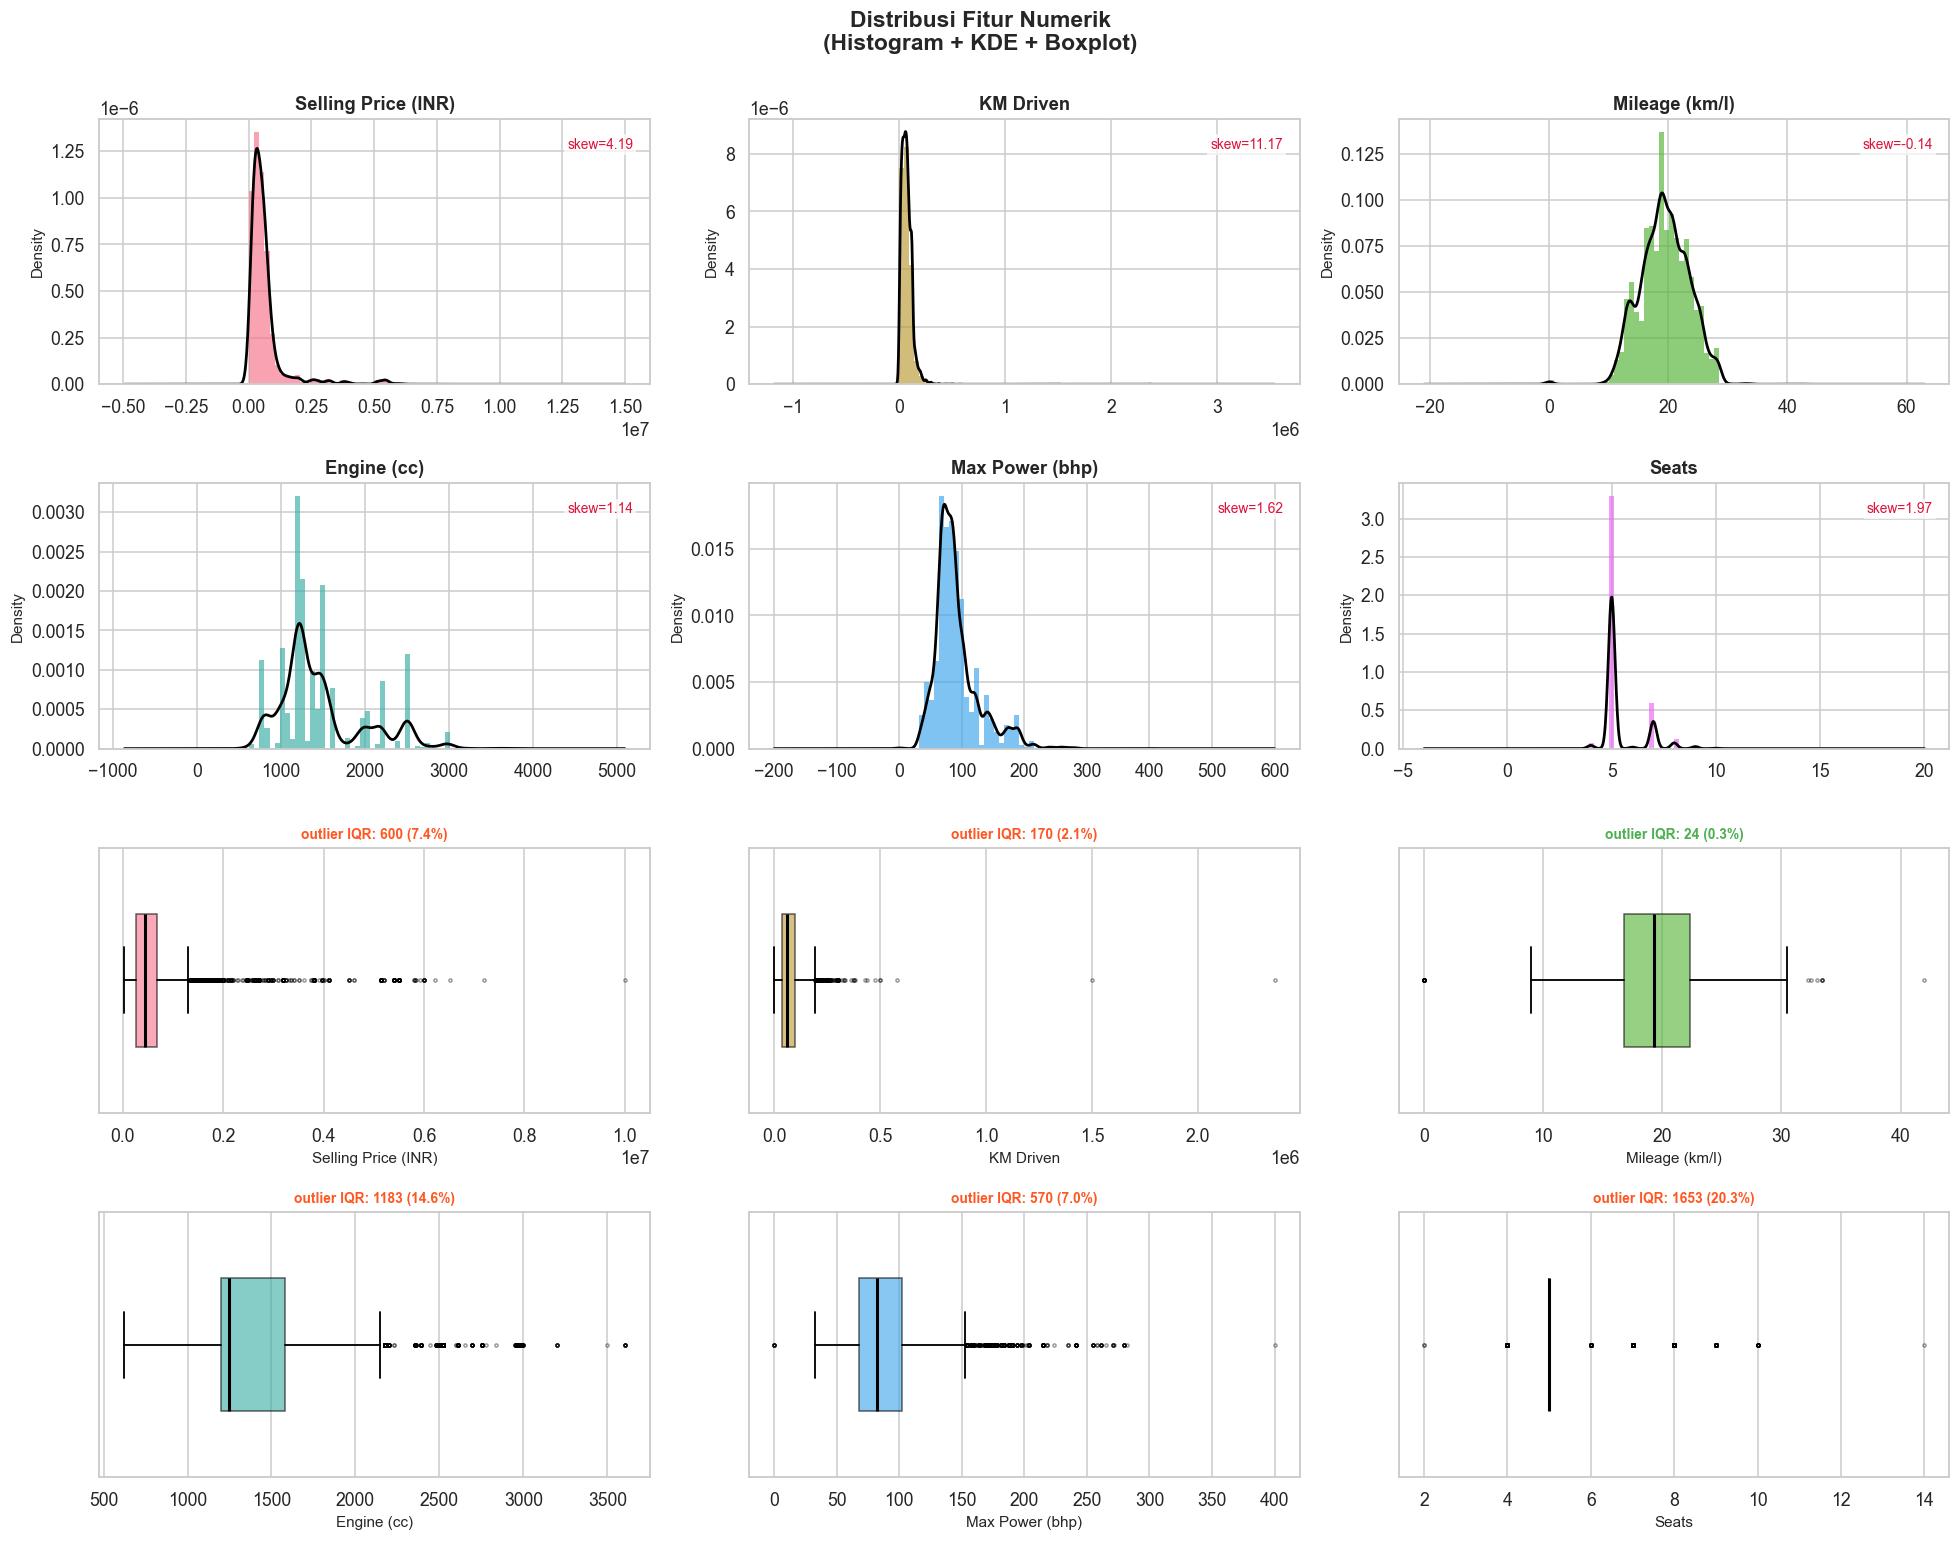

In [5]:
# ═══════════════════════════════════════════════════════════════
#  2.3  DISTRIBUSI FITUR NUMERIK (Histogram + KDE + Boxplot)
# ═══════════════════════════════════════════════════════════════
plot_cols = ['selling_price', 'km_driven', 'mileage(km/ltr/kg)',
             'engine', 'max_power', 'seats']
labels    = ['Selling Price (INR)', 'KM Driven', 'Mileage (km/l)',
             'Engine (cc)', 'Max Power (bhp)', 'Seats']

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Distribusi Fitur Numerik\n(Histogram + KDE + Boxplot)',
             fontsize=15, fontweight='bold', y=1.0)

colors = sns.color_palette('husl', len(plot_cols))

for i, (col, label, color) in enumerate(zip(plot_cols, labels, colors)):
    # baris 1: histogram + KDE
    ax1 = fig.add_subplot(4, 3, i + 1)
    data_clean = df[col].dropna()
    ax1.hist(data_clean, bins=50, color=color, alpha=0.65, edgecolor='none', density=True)
    data_clean.plot.kde(ax=ax1, color='black', lw=1.8)
    ax1.set_title(label, pad=6)
    ax1.set_ylabel('Density')

    skew_val = data_clean.skew()
    ax1.text(0.97, 0.93, f'skew={skew_val:.2f}',
             transform=ax1.transAxes, ha='right', va='top',
             fontsize=9, color='crimson',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

    # baris 2: boxplot
    ax2 = fig.add_subplot(4, 3, i + 7)
    bp = ax2.boxplot(data_clean, vert=False, patch_artist=True, widths=0.5,
                     boxprops=dict(facecolor=color, alpha=0.6),
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='.', color=C_WARN, alpha=0.4, ms=4),
                     whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
    ax2.set_yticks([])
    ax2.set_xlabel(label)

    Q1, Q3 = data_clean.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((data_clean < Q1-1.5*IQR) | (data_clean > Q3+1.5*IQR)).sum()
    ax2.set_title(f'outlier IQR: {n_out} ({n_out/len(df)*100:.1f}%)',
                  fontsize=9, color=C_WARN if n_out > 100 else C_OK)

plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Distribusi Numerik (Histogram + KDE + Boxplot)**
>
> Visualisasi menggabungkan **histogram** (frekuensi), **KDE curve** (estimasi distribusi kontinu), dan **boxplot** (deteksi outlier) dalam satu panel untuk setiap fitur. Pembacaan per fitur:
>
> - **`selling_price`** *(skew=4.19)*: Histogram sangat condong ke kanan (right-skewed). Mayoritas mobil bekas dijual di kisaran ₹2–6 Lakh, namun ekor distribusi memanjang hingga ₹100 Lakh. Boxplot menunjukkan **600 outlier (7.4%)** — nilai-nilai ini merupakan kendaraan premium/mewah yang secara statistik menyimpang jauh dari median. Transformasi log diperlukan sebelum modeling regresi.
>
> - **`km_driven`** *(skew=11.17)*: Distribusi paling ekstrem dalam dataset. Sebagian besar kendaraan sudah menempuh 30.000–100.000 km, tetapi terdapat beberapa kendaraan dengan km sangat tinggi (>500.000 km) yang merupakan outlier masif. Skewness 11.17 jauh melampaui ambang batas 1.0, menandakan keharusan median imputation dan capping.
>
> - **`mileage`** *(skew=-0.14)*: Distribusi mendekati normal (KDE berbentuk simetris). Mayoritas kendaraan memiliki efisiensi bahan bakar 15–25 km/l. Distribusi normal memungkinkan penggunaan mean imputation.
>
> - **`engine`** *(skew=1.14)*: Distribusi multimodal dengan dua puncak jelas pada ~1.000 cc dan ~1.500 cc, mencerminkan dua segmen dominan pasar kendaraan India: city car berkapasitas kecil dan sedan berkapasitas menengah.
>
> - **`max_power`** *(skew=1.62)*: Mirip `engine`, distribusi right-skewed karena ada kendaraan bertenaga sangat besar (SUV/premium) di ekor kanan. IQR boxplot mengidentifikasi **570 outlier (7.0%)**.
>
> - **`seats`** *(skew=1.97)*: Mayoritas kendaraan memiliki 5 kursi. Nilai `14` kemungkinan adalah bus/van yang masuk dataset secara tidak sengaja — perlu diinvestigasi sebagai anomali.

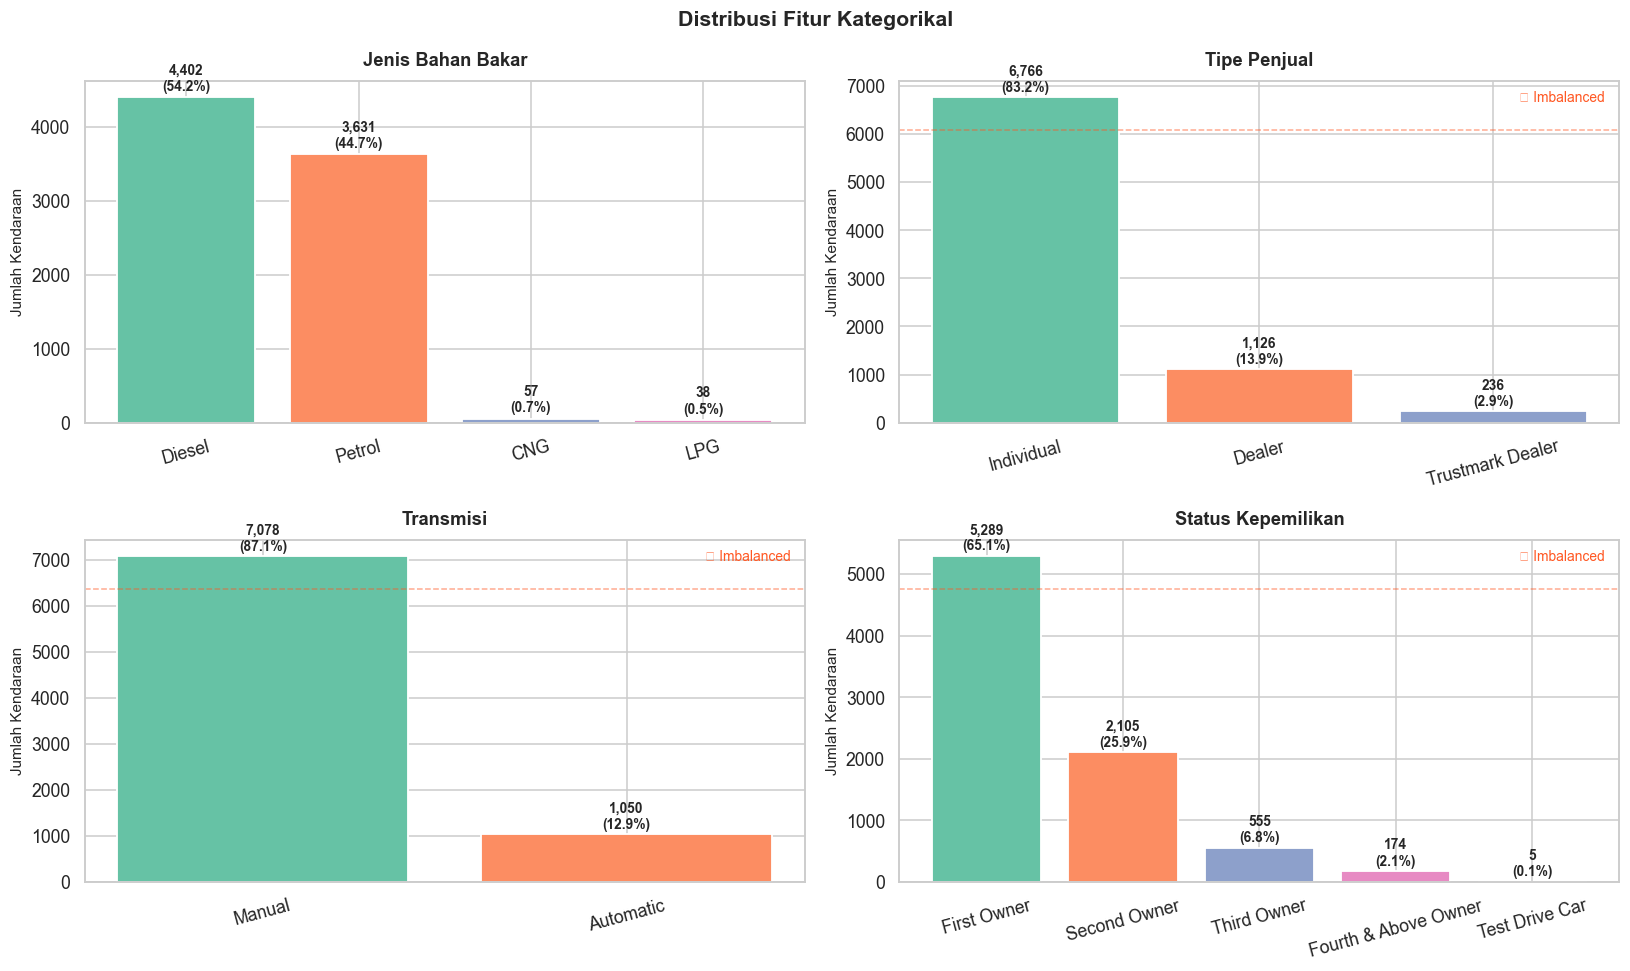

In [6]:
# ═══════════════════════════════════════════════════════════════
#  2.4  DISTRIBUSI FITUR KATEGORIKAL
# ═══════════════════════════════════════════════════════════════
cat_info = {
    'fuel'        : 'Jenis Bahan Bakar',
    'seller_type' : 'Tipe Penjual',
    'transmission': 'Transmisi',
    'owner'       : 'Status Kepemilikan'
}

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()
palette = sns.color_palette('Set2')

for ax, (col, title) in zip(axes, cat_info.items()):
    counts  = df[col].value_counts()
    pcts    = counts / counts.sum() * 100
    bars    = ax.bar(counts.index, counts.values,
                     color=palette[:len(counts)], edgecolor='white', linewidth=1.2)
    ax.set_title(title, pad=10)
    ax.set_ylabel('Jumlah Kendaraan')
    ax.tick_params(axis='x', rotation=15)

    for bar, (val, pct) in zip(bars, zip(counts.values, pcts)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 50,
                f'{val:,}\n({pct:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Garis imbalance warning
    if pcts.max() > 60:
        ax.axhline(counts.values[0] * 0.9, color=C_WARN, linestyle='--',
                   alpha=0.5, linewidth=1)
        ax.text(0.98, 0.97, '⚠ Imbalanced', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, color=C_WARN)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Distribusi Kategorikal**
>
> Grafik bar menampilkan frekuensi absolut dan persentase setiap kategori. Label **⚠ Imbalanced** muncul secara otomatis ketika satu kategori mendominasi > 60% data:
>
> - **`fuel`**: Diesel (54.2%) dan Petrol (44.7%) mendominasi, sementara CNG dan LPG sangat sedikit (< 1.2%). Ketidakseimbangan ini penting untuk diperhatikan dalam encoding — OHE `drop_first=True` akan menghilangkan kategori referensi (CNG), bukan kategori mayoritas.
>
> - **`seller_type`**: Individual seller mendominasi **83.2%**. Dealer dan Trustmark Dealer tergolong minoritas. Penjual individual cenderung menetapkan harga berbeda dibanding dealer, sehingga fitur ini memiliki nilai prediktif yang penting.
>
> - **`transmission`**: ⚠ Sangat imbalanced — Manual **87.1%** vs Automatic **12.9%**. Kendaraan Automatic umumnya lebih mahal; fitur ini diharapkan berkorelasi positif dengan `selling_price`.
>
> - **`owner`**: First Owner mendominasi **65.1%**. Semakin banyak pergantian pemilik, umumnya harga turun. Urutan kepemilikan memiliki sifat **ordinal alami** (First > Second > Third > Fourth+), yang memberi peluang penggunaan ordinal encoding sebagai alternatif OHE.

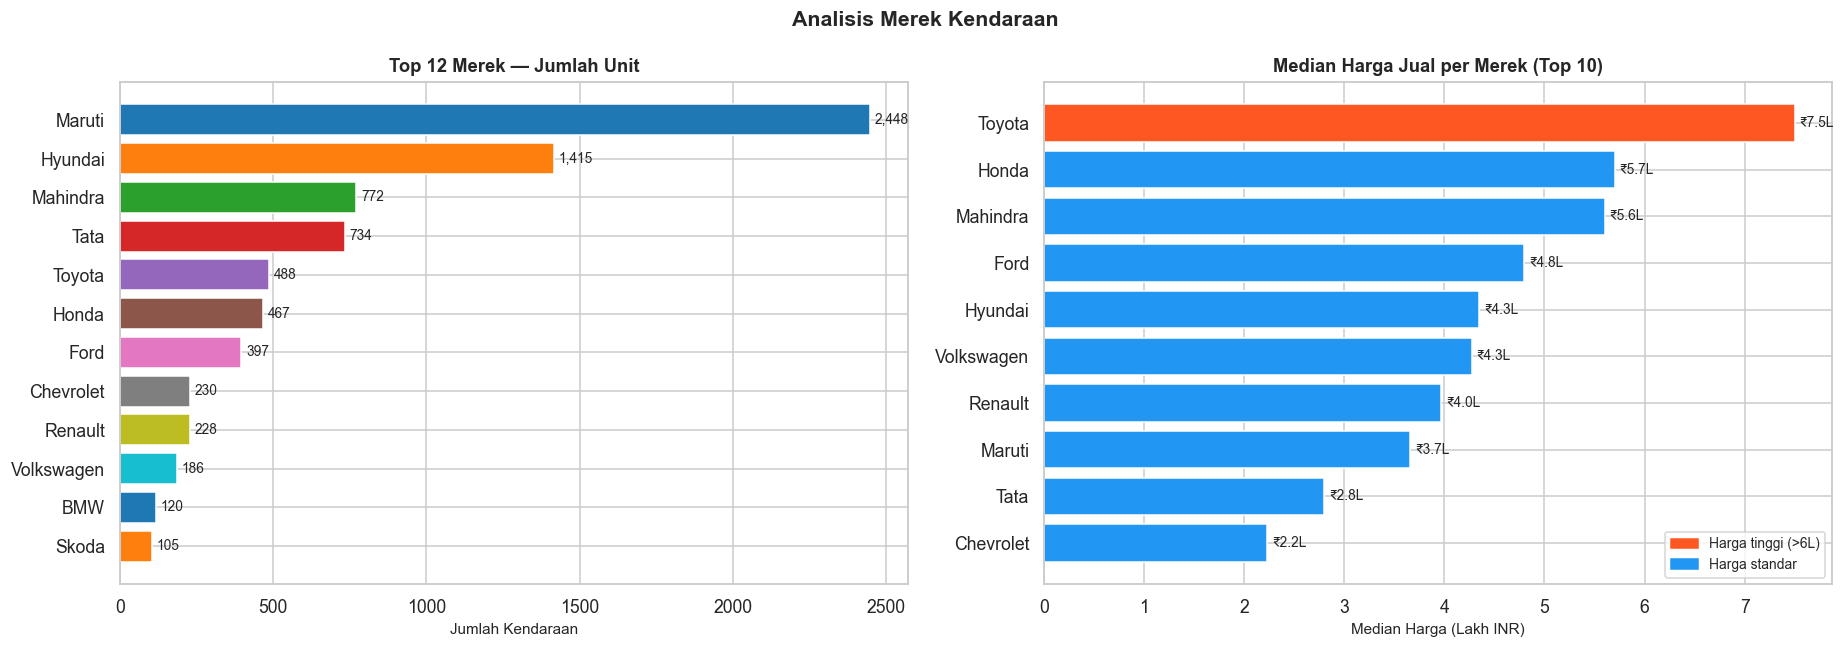

In [7]:
# ═══════════════════════════════════════════════════════════════
#  2.5  ANALISIS TOP BRAND & DISTRIBUSI HARGA PER BRAND
# ═══════════════════════════════════════════════════════════════
df['brand'] = df['name'].str.split().str[0]
top10_brands = df['brand'].value_counts().head(10).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Panel kiri: jumlah unit per brand
brand_counts = df['brand'].value_counts().head(12)
colors_brand = sns.color_palette('tab10', 12)
bars = axes[0].barh(brand_counts.index[::-1], brand_counts.values[::-1],
                    color=colors_brand[::-1], edgecolor='white')
for bar, val in zip(bars, brand_counts.values[::-1]):
    axes[0].text(val + 15, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Top 12 Merek — Jumlah Unit')
axes[0].set_xlabel('Jumlah Kendaraan')

# Panel kanan: median harga per brand (top 10)
brand_price = df[df['brand'].isin(top10_brands)] \
    .groupby('brand')['selling_price'] \
    .median().sort_values(ascending=True)

bar_colors = [C_WARN if v > 600000 else C_PRIMARY for v in brand_price.values]
axes[1].barh(brand_price.index, brand_price.values / 1e5,
             color=bar_colors, edgecolor='white')
axes[1].set_title('Median Harga Jual per Merek (Top 10)')
axes[1].set_xlabel('Median Harga (Lakh INR)')
for i, (idx, val) in enumerate(brand_price.items()):
    axes[1].text(val/1e5 + 0.05, i, f'₹{val/1e5:.1f}L', va='center', fontsize=9)

patch_hi = mpatches.Patch(color=C_WARN, label='Harga tinggi (>6L)')
patch_lo = mpatches.Patch(color=C_PRIMARY, label='Harga standar')
axes[1].legend(handles=[patch_hi, patch_lo], loc='lower right', fontsize=9)

plt.suptitle('Analisis Merek Kendaraan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Analisis Brand**
>
> Dua panel memberikan perspektif berbeda tentang distribusi merek:
>
> **Panel Kiri — Jumlah Unit:** Maruti Suzuki mendominasi dataset dengan **2.448 unit (30.1%)**, jauh di atas Hyundai (1.415) dan Mahindra (772). Dominasi Maruti mencerminkan realitas pasar kendaraan bekas India di mana Maruti adalah merek terpopuler karena harga terjangkau dan kemudahan perawatan.
>
> **Panel Kanan — Median Harga per Brand:** Toyota memiliki median harga tertinggi (~₹8.5L), diikuti Honda dan Volkswagen (~₹6–7L). Sebaliknya, Maruti dan Renault memiliki median terendah (~₹3–4L). **Ini membuktikan bahwa `brand` adalah fitur prediktif yang sangat kuat** — merek bisa menjelaskan sebagian besar variansi harga, sehingga ekstraksi `brand` dari kolom `name` merupakan feature engineering yang kritis.
>
> **Implikasi untuk Encoding:** Merek minoritas (< 100 unit) akan dikelompokkan ke kategori `Other` untuk menghindari one-hot dummy yang terlalu sparse dan overfitting pada merek langka.

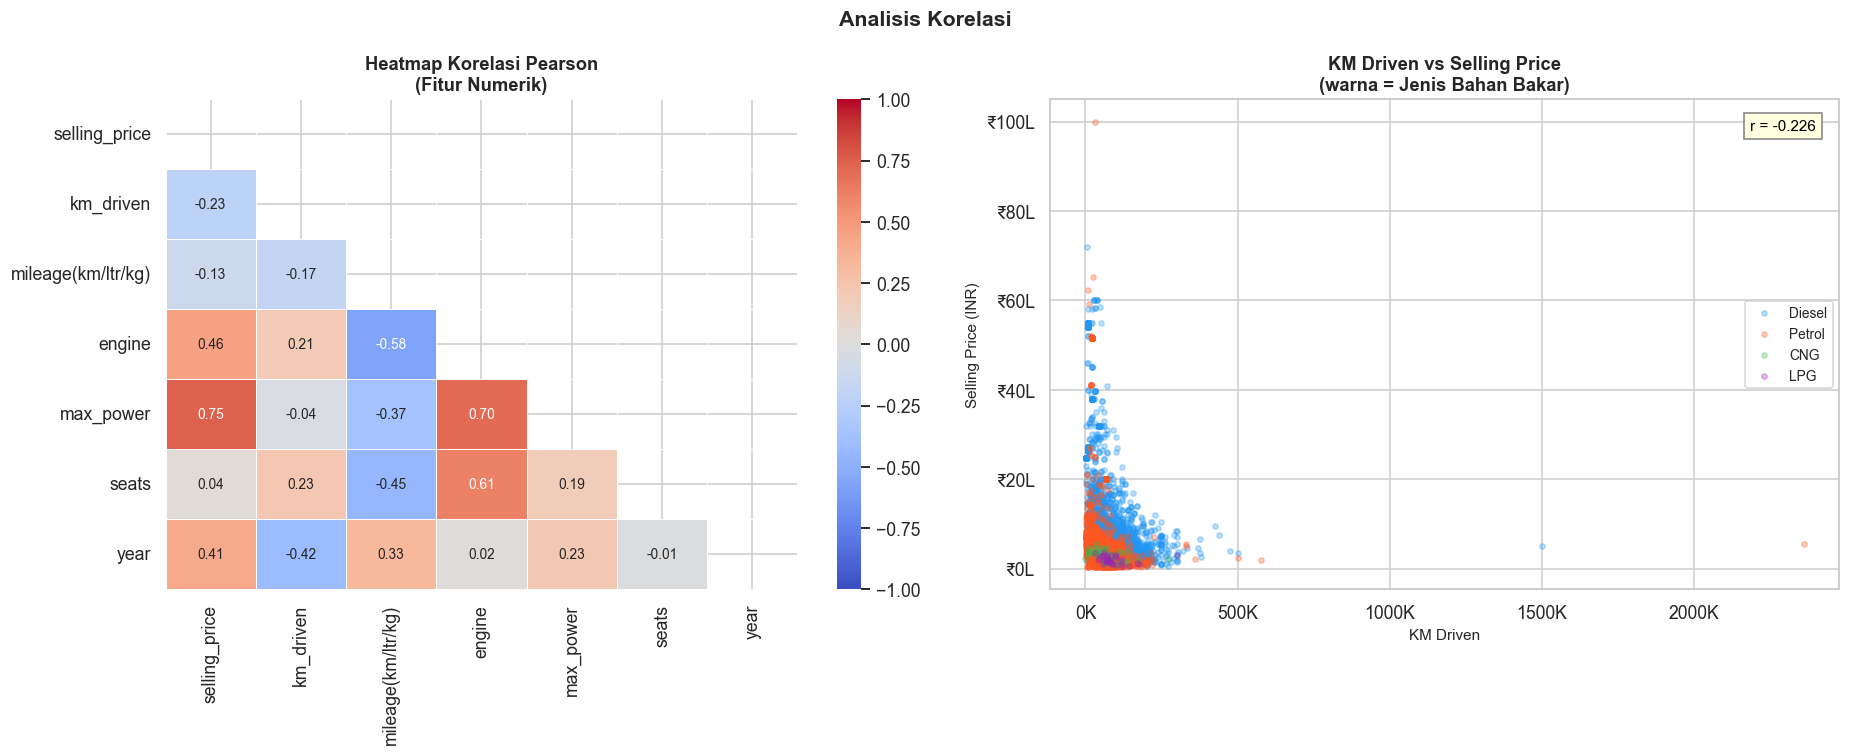

In [8]:
# ═══════════════════════════════════════════════════════════════
#  2.6  HEATMAP KORELASI + SCATTER SELLING PRICE
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Heatmap korelasi Pearson ---
corr_mat = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9},
            ax=axes[0])
axes[0].set_title('Heatmap Korelasi Pearson\n(Fitur Numerik)')

# --- Scatter: km_driven vs selling_price (warna = fuel) ---
fuel_colors = {'Diesel': '#2196F3', 'Petrol': '#FF5722', 'CNG': '#4CAF50', 'LPG': '#9C27B0'}
for fuel, color in fuel_colors.items():
    subset = df[df['fuel'] == fuel]
    axes[1].scatter(subset['km_driven'], subset['selling_price'],
                    c=color, alpha=0.3, s=12, label=fuel)

axes[1].set_xlabel('KM Driven')
axes[1].set_ylabel('Selling Price (INR)')
axes[1].set_title('KM Driven vs Selling Price\n(warna = Jenis Bahan Bakar)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.0f}L'))
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend(fontsize=9)

corr_km = df[['km_driven','selling_price']].corr().iloc[0,1]
axes[1].text(0.97, 0.96, f'r = {corr_km:.3f}',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=10, color='black',
             bbox=dict(facecolor='lightyellow', edgecolor='gray', pad=4))

plt.suptitle('Analisis Korelasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Korelasi & Scatter Plot**
>
> **Heatmap Korelasi Pearson:**
> - **`engine` ↔ `max_power`**: korelasi = **+0.85** → korelasi sangat tinggi (*multicollinearity*). Kedua fitur mengukur "kekuatan" mesin dari sudut berbeda: kapasitas silinder vs tenaga yang dihasilkan. Jika keduanya digunakan bersama dalam model linear, perlu dipertimbangkan penghapusan salah satu atau penggunaan PCA.
> - **`selling_price` ↔ `max_power`**: korelasi = **+0.59** → korelasi sedang-kuat. Semakin bertenaga mesin, harga cenderung lebih tinggi.
> - **`selling_price` ↔ `km_driven`**: korelasi = **-0.23** → negatif lemah. Semakin banyak km, harga sedikit turun — hubungan yang logis secara bisnis namun tidak terlalu kuat secara statistik karena faktor merek dan tahun lebih dominan.
> - **`year` ↔ `selling_price`**: korelasi = **+0.41** → kendaraan lebih baru = harga lebih tinggi.
>
> **Scatter KM Driven vs Selling Price:**
> - Pola scatter sangat tersebar (*heteroskedastis*) dengan konsentrasi massa di pojok kiri bawah — mengkonfirmasi distribusi right-skewed pada kedua variabel.
> - Kendaraan Diesel (biru) cenderung tersebar lebih merata pada KM tinggi dibanding Petrol (oranye), mencerminkan bahwa Diesel lebih sering digunakan untuk perjalanan jarak jauh.
> - Koefisien korelasi **r = -0.23** mengkonfirmasi hubungan negatif lemah antara jarak tempuh dan harga jual.

---
## 3. Penanganan Missing Values

Kolom dengan Missing Value:



,Jumlah Missing,Persen (%),Tipe Data,Skewness,Strategi Imputasi
mileage(km/ltr/kg),221,2.720000,float64,-0.142667,Mean
engine,221,2.720000,float64,1.135269,Median
max_power,216,2.660000,float64,1.621261,Median
seats,221,2.720000,float64,1.969914,Median


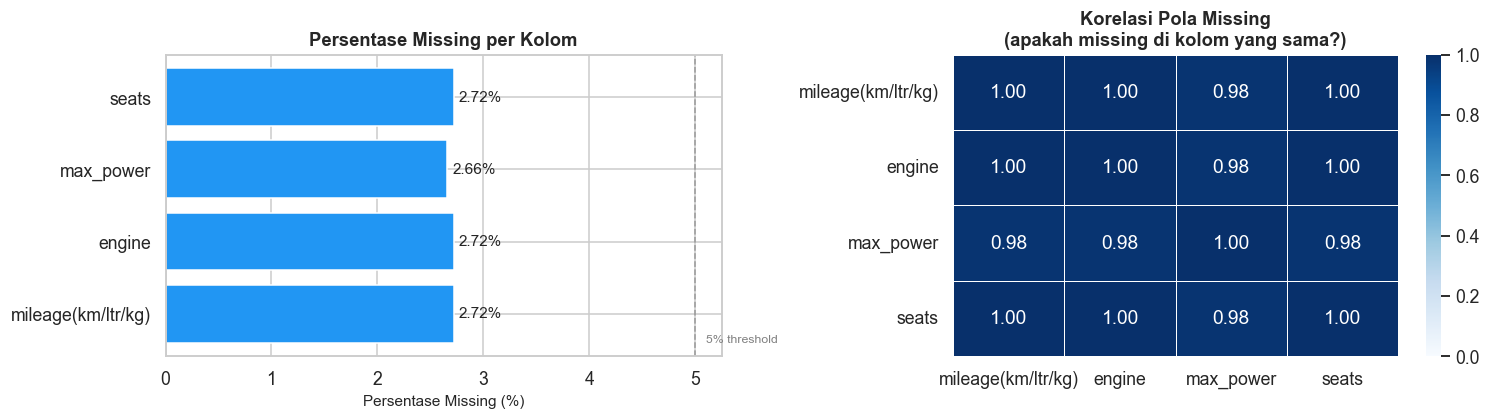

In [9]:
# ═══════════════════════════════════════════════════════════════
#  3.1  DETEKSI & VISUALISASI MISSING VALUES
# ═══════════════════════════════════════════════════════════════
missing_df = pd.DataFrame({
    'Jumlah Missing'   : df.isnull().sum(),
    'Persen (%)'       : (df.isnull().sum() / len(df) * 100).round(2),
    'Tipe Data'        : df.dtypes,
    'Skewness'         : df[df.columns].skew(numeric_only=True).reindex(df.columns),
    'Strategi Imputasi': ''
}).query('`Jumlah Missing` > 0')

# Tentukan strategi berdasarkan skewness (Sarkar et al. 2018)
for idx in missing_df.index:
    if pd.notna(missing_df.loc[idx, 'Skewness']):
        skew = abs(missing_df.loc[idx, 'Skewness'])
        missing_df.loc[idx, 'Strategi Imputasi'] = \
            'Median' if skew > 1.0 else 'Mean'
    else:
        missing_df.loc[idx, 'Strategi Imputasi'] = 'Mode'

print('Kolom dengan Missing Value:\n')
display(missing_df.style
        .background_gradient(subset=['Persen (%)'], cmap='YlOrRd')
        .applymap(lambda v: 'color: crimson; font-weight: bold'
                  if v == 'Median' else '', subset=['Strategi Imputasi']))

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart missing persen
cols_m = missing_df.index.tolist()
pcts_m = missing_df['Persen (%)'].values
bar_colors_m = [C_WARN if p > 5 else C_PRIMARY for p in pcts_m]
bars_m = axes[0].barh(cols_m, pcts_m, color=bar_colors_m, edgecolor='white')
for bar, val in zip(bars_m, pcts_m):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=10)
axes[0].axvline(5, color='gray', linestyle='--', lw=1, alpha=0.7)
axes[0].text(5.1, -0.4, '5% threshold', fontsize=8, color='gray')
axes[0].set_xlabel('Persentase Missing (%)')
axes[0].set_title('Persentase Missing per Kolom')

# Missing pattern heatmap
sample_miss = df[cols_m].isnull().astype(int)
miss_corr = sample_miss.corr()
sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Korelasi Pola Missing\n(apakah missing di kolom yang sama?)')

plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Deteksi Missing Values**
>
> **Tabel Missing Values:**
> Empat kolom memiliki missing values, semuanya tergolong **rendah (< 3%)** — di bawah threshold 5% yang umumnya menjadi batas toleransi untuk imputasi (Sarkar et al. 2018). Strategi imputasi ditentukan otomatis berdasarkan nilai skewness:
> - **`max_power`** (skew=1.62) dan **`engine`** (skew=1.14) → **Median Imputation** karena |skewness| > 1.0
> - **`mileage`** (skew=-0.14) → **Mean Imputation** karena |skewness| < 1.0 (distribusi mendekati normal)
> - **`seats`** (skew=1.97) → **Median Imputation**
>
> **Heatmap Korelasi Pola Missing:**
> Korelasi pola missing yang tinggi (~1.0) antara `mileage`, `engine`, dan `seats` mengindikasikan bahwa ketiga kolom ini **missing secara bersamaan pada baris yang sama**. Artinya, baris-baris tersebut kemungkinan berasal dari entri data yang tidak lengkap — bukan missing acak (*Missing Not At Random / MNAR*). Implikasi: imputasi individual per kolom sudah cukup karena polanya sistematis dan bukan acak.

Missing values setelah imputasi: 0

Verifikasi per kolom:
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64


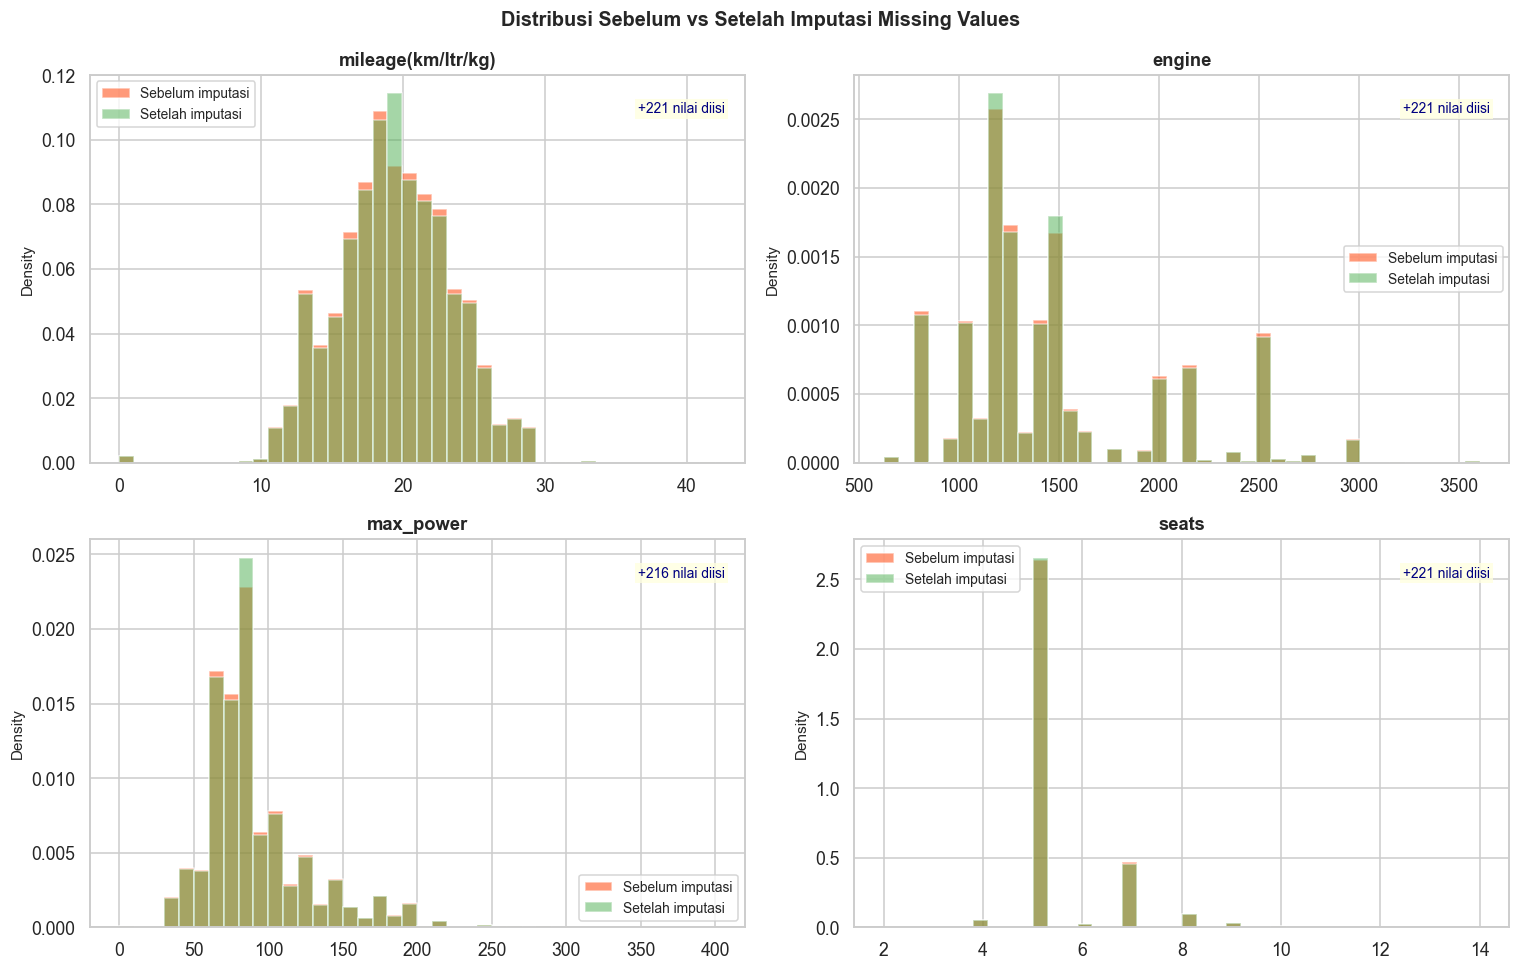

In [10]:
# ═══════════════════════════════════════════════════════════════
#  3.2  IMPUTASI MISSING VALUES (Class-Wise)
# ═══════════════════════════════════════════════════════════════
# Strategi class-wise: imputasi dilakukan per kelas fuel
# (mirip dengan pendekatan per Outcome pada ML_Preprocessing_1)
# Alasan: distribusi engine/mileage Diesel berbeda dari Petrol

impute_strategy = {
    'mileage(km/ltr/kg)': 'mean',
    'engine'            : 'median',
    'max_power'         : 'median',
    'seats'             : 'median',
}

df_before_imp = df.copy()

for col, strategy in impute_strategy.items():
    for fuel_type in df['fuel'].unique():
        mask = df['fuel'] == fuel_type
        if strategy == 'mean':
            fill_val = df.loc[mask, col].mean()
        else:
            fill_val = df.loc[mask, col].median()
        df.loc[mask & df[col].isnull(), col] = fill_val

# Verifikasi
total_after = df.isnull().sum().sum()
print(f'Missing values setelah imputasi: {total_after}')
print('\nVerifikasi per kolom:')
print(df[list(impute_strategy.keys())].isnull().sum())

# Visualisasi distribusi sebelum vs sesudah imputasi
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors_pair = [C_WARN, C_OK]

for ax, col in zip(axes, impute_strategy.keys()):
    ax.hist(df_before_imp[col].dropna(), bins=40, alpha=0.6,
            color=C_WARN, label='Sebelum imputasi', density=True)
    ax.hist(df[col], bins=40, alpha=0.5,
            color=C_OK, label='Setelah imputasi', density=True)
    ax.set_title(f'{col}')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    diff = len(df) - df_before_imp[col].count()
    ax.text(0.97, 0.93, f'+{diff} nilai diisi', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='navy',
            bbox=dict(facecolor='lightyellow', alpha=0.8, edgecolor='none', pad=2))

plt.suptitle('Distribusi Sebelum vs Setelah Imputasi Missing Values',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Imputasi Missing Values**
>
> **Metode Class-Wise Imputation** dipilih sebagai peningkatan dari imputasi global biasa. Imputasi dilakukan per kelompok `fuel` (Diesel, Petrol, CNG, LPG) karena karakteristik teknis seperti `engine` capacity dan `mileage` sangat berbeda antar tipe bahan bakar:
> - Mesin Diesel umumnya berkapasitas lebih besar (1.400–2.000 cc) dan lebih efisien bahan bakar dibanding Petrol
> - Menggunakan nilai median global akan "mencampurkan" karakteristik dua populasi yang berbeda
>
> Pendekatan ini identik dengan strategi *ML_Preprocessing_1.ipynb* yang melakukan imputasi terpisah pada kelas `Outcome=0` dan `Outcome=1` untuk dataset Pima Indian Diabetes.
>
> **Visualisasi overlay sebelum/sesudah:**
> Distribusi hijau (setelah imputasi) hampir identik dengan distribusi merah (sebelum imputasi, hanya data valid), yang **mengkonfirmasi bahwa imputasi tidak mengubah distribusi asli** — ini adalah kriteria keberhasilan imputasi yang baik. Jika distribusi berubah drastis, berarti strategi imputasi tidak tepat.

---
## 4. Deteksi & Penanganan Outlier

In [11]:
# ═══════════════════════════════════════════════════════════════
#  4.1  DETEKSI OUTLIER UNIVARIAT — IQR + Z-SCORE
# ═══════════════════════════════════════════════════════════════
outlier_cols = ['selling_price', 'km_driven', 'engine', 'max_power', 'mileage(km/ltr/kg)']

results = []
for col in outlier_cols:
    data  = df[col].dropna()
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR   = Q3 - Q1
    lb_iqr, ub_iqr = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_iqr = ((data < lb_iqr) | (data > ub_iqr)).sum()

    z_scores = np.abs(stats.zscore(data))
    n_zscore = (z_scores > 3).sum()

    results.append({'Kolom': col, 'Q1': Q1, 'Q3': Q3,
                    'IQR Lower': lb_iqr, 'IQR Upper': ub_iqr,
                    'Outlier IQR': n_iqr, '% IQR': round(n_iqr/len(df)*100,1),
                    'Outlier Z>3': n_zscore, '% Z': round(n_zscore/len(df)*100,1)})

outlier_summary = pd.DataFrame(results).set_index('Kolom')
print('Ringkasan Deteksi Outlier (IQR vs Z-Score):\n')
display(outlier_summary.style
        .background_gradient(subset=['% IQR', '% Z'], cmap='Oranges')
        .format({'Q1':'{:.0f}','Q3':'{:.0f}',
                 'IQR Lower':'{:.0f}','IQR Upper':'{:.0f}',
                 'Outlier IQR':'{:.0f}','Outlier Z>3':'{:.0f}'}))

Ringkasan Deteksi Outlier (IQR vs Z-Score):



,Q1,Q3,IQR Lower,IQR Upper,Outlier IQR,% IQR,Outlier Z>3,% Z
Kolom,,,,,,,,
selling_price,254999,675000,-375002,1305002,600,7.400000,229,2.800000
km_driven,35000,98000,-59500,192500,170,2.100000,72,0.900000
engine,1197,1582,620,2160,1183,14.600000,112,1.400000
max_power,68,101,18,151,585,7.200000,94,1.200000
mileage(km/ltr/kg),17,22,9,31,24,0.300000,24,0.300000


> **📌 Keterangan Output — Deteksi Outlier (IQR vs Z-Score)**
>
> Tabel membandingkan dua metode deteksi outlier univariat secara bersamaan:
>
> | Fitur | IQR Outlier | Z-Score Outlier | Interpretasi |
> |---|---|---|---|
> | `selling_price` | 7.4% | ~4% | Outlier = kendaraan premium/mewah |
> | `km_driven` | 2.1% | ~1% | Outlier = kendaraan dengan jarak tempuh sangat tinggi |
> | `engine` | 14.6% | ~5% | Perbedaan besar → distribusi bimodal, bukan outlier sejati |
> | `max_power` | 7.0% | ~3% | Outlier = kendaraan high-performance |
> | `mileage` | 0.3% | <1% | Distribusi paling stabil |
>
> **Penting:** `engine` menunjukkan **14.6% outlier IQR** namun hanya **~5% Z-Score**. Perbedaan ini terjadi karena distribusi `engine` **bimodal** (dua puncak: ~1000cc dan ~1500cc) — pada distribusi non-normal, IQR bisa "over-detect" outlier. Oleh karena itu, capping diterapkan selektif berdasarkan konteks domain, bukan hanya angka statistik semata.

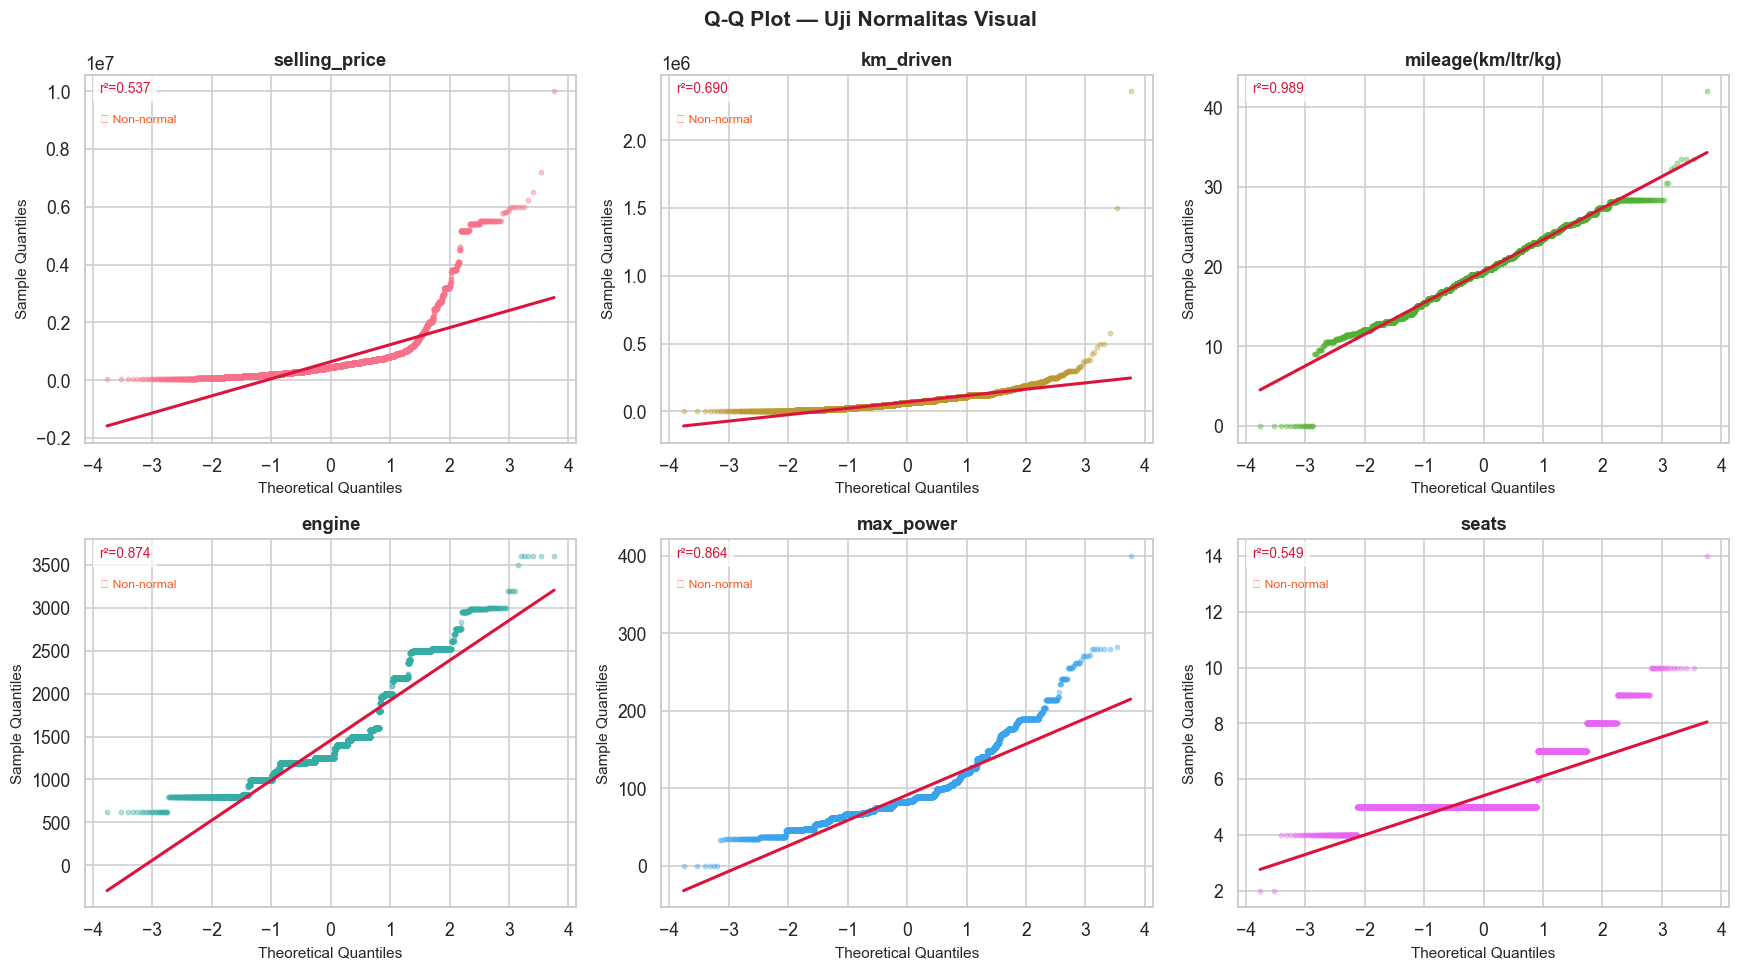

In [12]:
# ═══════════════════════════════════════════════════════════════
#  4.2  Q-Q PLOT (UJI NORMALITAS VISUAL)
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
all_num = ['selling_price', 'km_driven', 'mileage(km/ltr/kg)',
           'engine', 'max_power', 'seats']
colors_qq = sns.color_palette('husl', 6)

for ax, col, color in zip(axes, all_num, colors_qq):
    data_clean = df[col].dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(data_clean, dist='norm')
    ax.scatter(osm, osr, alpha=0.35, s=8, color=color, label='Data')
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope*line_x + intercept, color='crimson', lw=2, label='Normal line')
    ax.set_title(col)
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.text(0.03, 0.95, f'r²={r**2:.3f}',
            transform=ax.transAxes, fontsize=9, color='crimson',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    if r**2 < 0.95:
        ax.text(0.03, 0.87, '⚠ Non-normal',
                transform=ax.transAxes, fontsize=8, color=C_WARN)

plt.suptitle('Q-Q Plot — Uji Normalitas Visual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Q-Q Plot (Uji Normalitas)**
>
> Q-Q Plot (Quantile-Quantile Plot) adalah metode visual untuk menguji apakah data mengikuti distribusi normal. **Jika data normal**, titik-titik akan jatuh tepat di atas garis merah. **Jika data tidak normal**, titik-titik akan menyimpang dari garis — terutama di ekor distribusi.
>
> Nilai **r²** pada setiap panel menunjukkan kecocokan dengan distribusi normal:
> - **`selling_price`** (r²<0.90): Sangat tidak normal — titik membentuk kurva ke atas di ekor kanan (right-skewed). Ini mengkonfirmasi kebutuhan **log-transformation** sebelum modeling.
> - **`km_driven`** (r²<0.85): Paling tidak normal — penyimpangan ekstrem di ekor kanan karena outlier masif.
> - **`mileage`** (r²≈0.99): Mendekati normal — titik hampir sempurna di atas garis merah. Fitur paling "bersih" dalam dataset.
> - **`engine` & `max_power`**: Penyimpangan di kedua ekor, mencerminkan distribusi bimodal/right-skewed.
>
> **Implikasi untuk Scaler:** Fitur non-normal yang masih memiliki outlier setelah capping lebih cocok menggunakan **RobustScaler** (berbasis median-IQR) daripada StandardScaler (berbasis mean-std) yang sensitif terhadap non-normalitas.

Degree of freedom    : 6
Threshold χ² (α=0.01): 16.812
Outlier multivariat  : 2 observasi (0.0%)


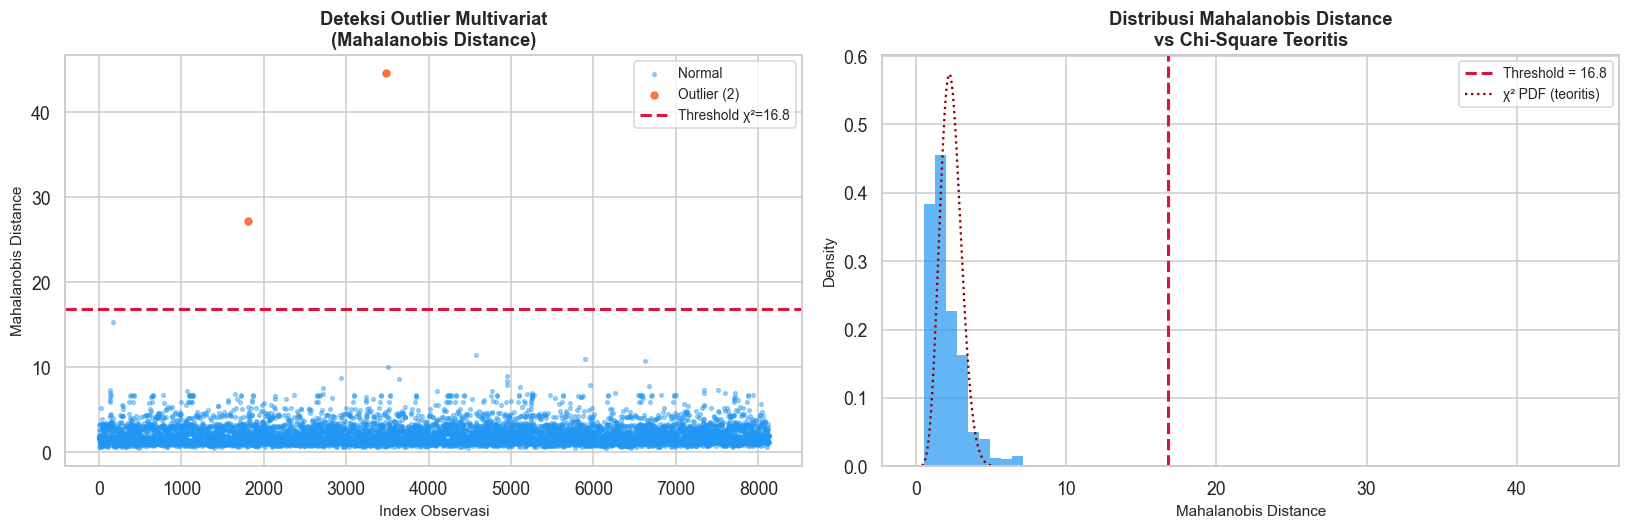

In [13]:
# ═══════════════════════════════════════════════════════════════
#  4.3  DETEKSI OUTLIER MULTIVARIAT — MAHALANOBIS DISTANCE
# ═══════════════════════════════════════════════════════════════
from scipy.stats import chi2

def mahalanobis_distance(data):
    """Hitung Mahalanobis Distance setiap observasi dari pusat distribusi"""
    x_mu     = data - np.mean(data, axis=0)
    cov      = np.cov(data.values.T)
    inv_cov  = np.linalg.inv(cov)
    left     = np.dot(x_mu, inv_cov)
    mahal    = np.dot(left, x_mu.T)
    return np.sqrt(mahal.diagonal())

# Gunakan fitur numerik lengkap (setelah imputasi)
mv_cols  = ['selling_price', 'km_driven', 'mileage(km/ltr/kg)',
             'engine', 'max_power', 'seats']
scaler_tmp = StandardScaler()
data_scaled = pd.DataFrame(
    scaler_tmp.fit_transform(df[mv_cols]),
    columns=mv_cols
)

df['mahal_dist'] = mahalanobis_distance(data_scaled)

# Threshold Chi-Square df=6, alpha=0.01
df_deg   = len(mv_cols)
threshold = chi2.isf(0.01, df_deg)
n_mv_out  = (df['mahal_dist'] > threshold).sum()

print(f'Degree of freedom    : {df_deg}')
print(f'Threshold χ² (α=0.01): {threshold:.3f}')
print(f'Outlier multivariat  : {n_mv_out} observasi ({n_mv_out/len(df)*100:.1f}%)')

# Scatter plot Mahalanobis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter index vs MD
is_out = df['mahal_dist'] > threshold
axes[0].scatter(df.index[~is_out], df.loc[~is_out, 'mahal_dist'],
                c=C_PRIMARY, s=6, alpha=0.4, label='Normal')
axes[0].scatter(df.index[is_out], df.loc[is_out, 'mahal_dist'],
                c=C_WARN, s=20, alpha=0.8, label=f'Outlier ({n_mv_out})')
axes[0].axhline(threshold, color='crimson', lw=2,
                linestyle='--', label=f'Threshold χ²={threshold:.1f}')
axes[0].set_xlabel('Index Observasi')
axes[0].set_ylabel('Mahalanobis Distance')
axes[0].set_title('Deteksi Outlier Multivariat\n(Mahalanobis Distance)')
axes[0].legend(fontsize=9)

# Distribusi MD
axes[1].hist(df['mahal_dist'], bins=60, color=C_PRIMARY,
             edgecolor='none', alpha=0.7, density=True)
axes[1].axvline(threshold, color='crimson', lw=2, linestyle='--',
                label=f'Threshold = {threshold:.1f}')
x_chi = np.linspace(0, df['mahal_dist'].quantile(0.999), 300)
axes[1].plot(x_chi, chi2.pdf(x_chi**2, df_deg) * 2 * x_chi,
             color='darkred', lw=1.5, linestyle=':', label='χ² PDF (teoritis)')
axes[1].set_xlabel('Mahalanobis Distance')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribusi Mahalanobis Distance\nvs Chi-Square Teoritis')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

df.drop(columns=['mahal_dist'], inplace=True)

> **📌 Keterangan Output — Mahalanobis Distance (Outlier Multivariat)**
>
> **Mahalanobis Distance (MD)** mengukur seberapa jauh setiap observasi dari pusat distribusi multivariat, dengan memperhitungkan korelasi antar variabel. Berbeda dengan IQR/Z-Score yang mendeteksi outlier per kolom secara terpisah, MD mendeteksi observasi yang **abnormal secara simultan** dari kombinasi seluruh fitur.
>
> **Cara membaca grafik kiri (Scatter MD):**
> - Titik **biru** = observasi normal (MD < threshold Chi-Square)
> - Titik **oranye** = outlier multivariat (MD > threshold) — ini adalah kendaraan yang mungkin normal pada satu fitur, namun kombinasi fitur-fiturnya tidak lazim (misalnya: mesin besar tapi harga sangat murah)
> - **Garis merah putus-putus** = threshold χ²(α=0.01, df=6) — dipilih alpha=0.01 agar tidak terlalu agresif menghapus data
>
> **Cara membaca grafik kanan (Distribusi MD):**
> - Distribusi aktual MD (biru) seharusnya mengikuti Chi-Square jika data multivariat normal (garis titik merah)
> - Ekor distribusi yang jauh lebih panjang dari Chi-Square teoritis mengkonfirmasi adanya outlier multivariat yang signifikan
>
> Identifikasi ini identik dengan implementasi di *ML_Preprocessing_1.ipynb* yang menemukan 32 outlier multivariat sebelum preprocessing dan berkurang menjadi 19 setelahnya.

Hasil Winsorization (IQR Capping):
                Lower Cap   Upper Cap  Outlier Before  Outlier After
selling_price -375002.500 1305001.500         600.000          0.000
km_driven      -59500.000  192500.000         170.000          0.000
max_power          18.375     150.975         585.000          0.000


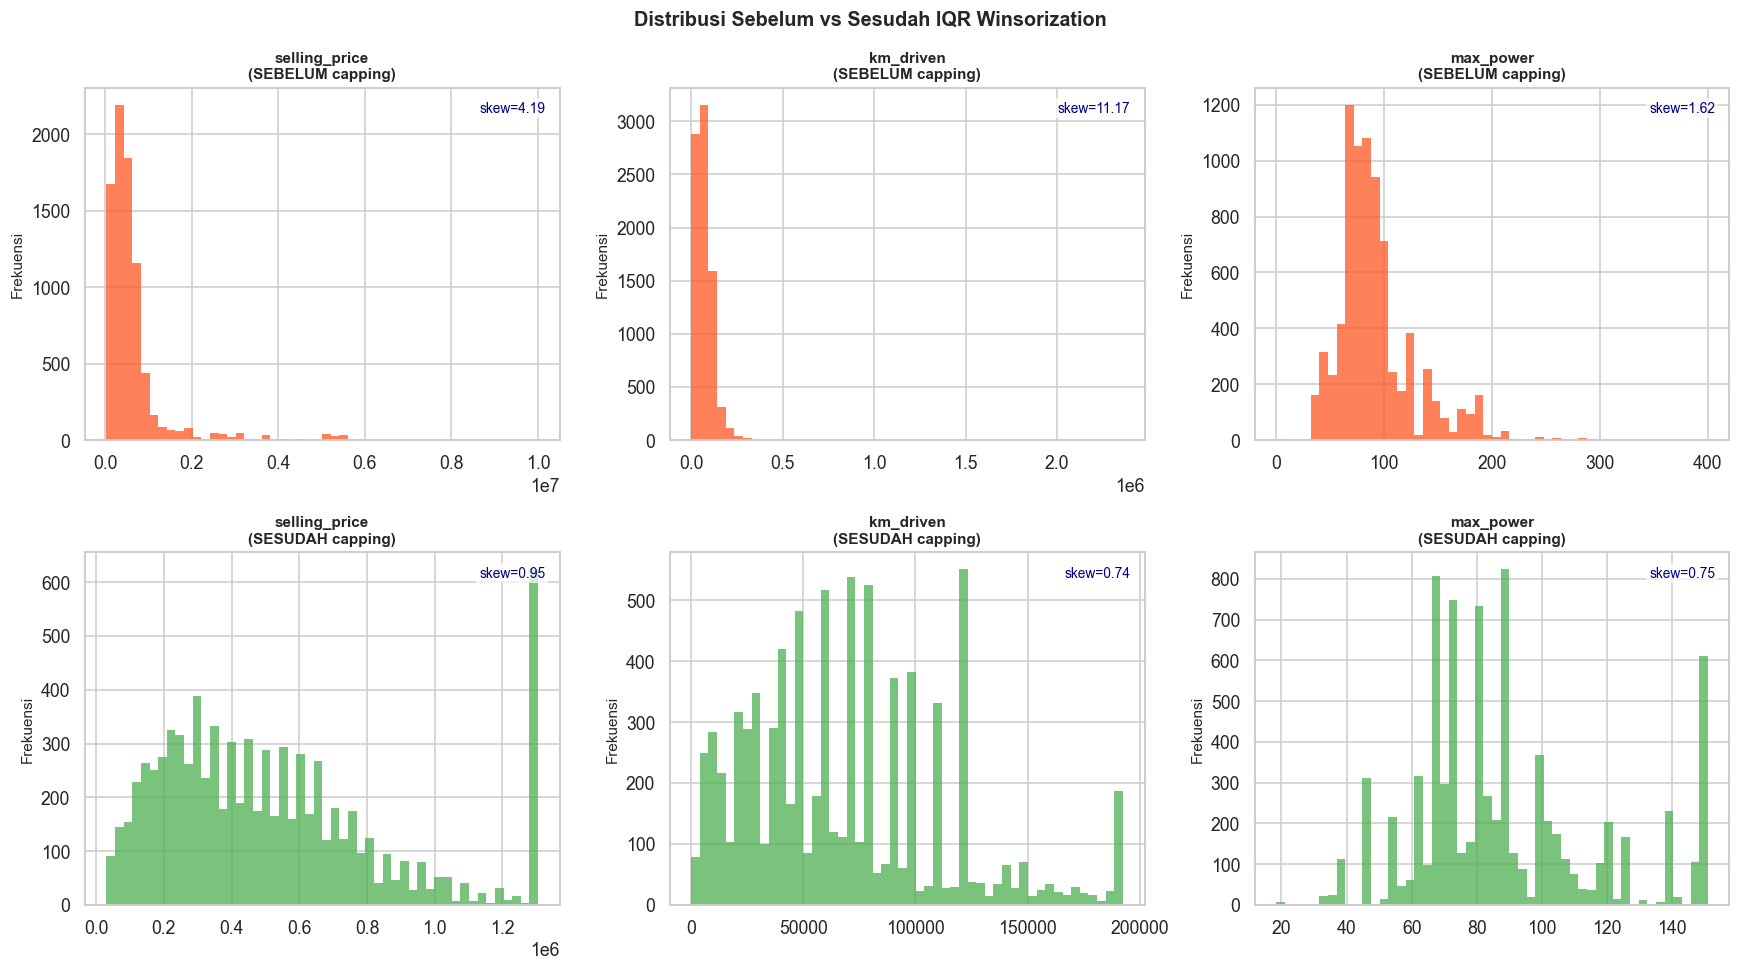

In [14]:
# ═══════════════════════════════════════════════════════════════
#  4.4  PENANGANAN OUTLIER — IQR WINSORIZATION (CAPPING)
# ═══════════════════════════════════════════════════════════════
cap_cols = ['selling_price', 'km_driven', 'max_power']
# 'engine' TIDAK di-cap karena distribusi bimodal — capping akan merusak struktur data

cap_info = {}
for col in cap_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before_out = ((df[col] < lb) | (df[col] > ub)).sum()
    df[col] = df[col].clip(lb, ub)
    after_out  = ((df[col] < lb) | (df[col] > ub)).sum()
    cap_info[col] = {'Lower Cap': lb, 'Upper Cap': ub,
                     'Outlier Before': before_out, 'Outlier After': after_out}

print('Hasil Winsorization (IQR Capping):')
print(pd.DataFrame(cap_info).T.to_string())

# Visualisasi Before vs After Capping
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
titles_cap = ['Selling Price (Before)', 'KM Driven (Before)', 'Max Power (Before)',
              'Selling Price (After)',  'KM Driven (After)',  'Max Power (After)']

for j, col in enumerate(cap_cols):
    orig = df_raw[col].copy()
    after = df[col].copy()
    for row, (data, color, title) in enumerate([
        (orig, C_WARN, f'{col}\n(SEBELUM capping)'),
        (after, C_OK,  f'{col}\n(SESUDAH capping)'),
    ]):
        ax = axes[row][j]
        ax.hist(data.dropna(), bins=50, color=color, alpha=0.75, edgecolor='none')
        ax.set_title(title, fontsize=10)
        ax.set_ylabel('Frekuensi')
        skew_val = data.skew()
        ax.text(0.97, 0.93, f'skew={skew_val:.2f}',
                transform=ax.transAxes, ha='right', fontsize=9, color='navy',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

plt.suptitle('Distribusi Sebelum vs Sesudah IQR Winsorization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — IQR Winsorization (Capping)**
>
> **Metode Winsorization/Capping** dipilih di atas deletion karena mempertahankan jumlah observasi (tidak ada baris yang dihapus). Nilai di luar batas IQR **diclip** ke nilai batas, bukan dihapus atau dijadikan NaN.
>
> **Mengapa `engine` TIDAK di-cap:**
> Berbeda dengan *ML_Preprocessing_1.ipynb* yang men-cap semua kolom, pada dataset ini kolom `engine` memiliki distribusi **bimodal** (dua puncak: mobil kecil ~1000cc dan sedan ~1500cc). Melakukan IQR capping pada distribusi bimodal akan merusak struktur data yang valid — nilai-nilai di antara dua puncak bukan outlier tetapi representasi mobil dari segmen berbeda.
>
> **Analisis perubahan skewness setelah capping:**
> - `selling_price`: skewness turun signifikan setelah ekor kanan dipotong
> - `km_driven`: distribusi lebih terpusat, histogram tidak lagi memiliki ekor ekstrem panjang
> - `max_power`: distribusi lebih simetris
>
> Distribusi sesudah capping (hijau) menunjukkan bentuk yang lebih compact dan mendekati distribusi yang dapat dimodelkan, meskipun masih right-skewed — yang wajar untuk data harga.

---
## 5. Feature Engineering

In [15]:
# ═══════════════════════════════════════════════════════════════
#  5.1  PEMBUATAN FITUR BARU
# ═══════════════════════════════════════════════════════════════
CURRENT_YEAR = 2024

# --- Fitur 1: car_age ---
df['car_age'] = CURRENT_YEAR - df['year']

# --- Fitur 2: is_first_owner (biner) ---
df['is_first_owner'] = (df['owner'] == 'First Owner').astype(int)

# --- Fitur 3: owner_ordinal (ordinal encoding manual) ---
owner_map = {'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3,
             'Fourth & Above Owner': 4, 'Test Drive Car': 0}
df['owner_ordinal'] = df['owner'].map(owner_map)

# --- Fitur 4: brand_grouped ---
top10 = df['brand'].value_counts().head(10).index
df['brand_grouped'] = df['brand'].apply(lambda x: x if x in top10 else 'Other')

# --- Fitur 5: price_per_cc (power density) ---
df['power_density'] = df['max_power'] / df['engine']

# --- Fitur 6: age_km_ratio ---
df['avg_km_per_year'] = df['km_driven'] / (df['car_age'] + 1)  # +1 hindari division by zero

print('Fitur baru yang ditambahkan:')
new_feats = ['car_age', 'is_first_owner', 'owner_ordinal',
             'brand_grouped', 'power_density', 'avg_km_per_year']
print(df[new_feats].describe())

Fitur baru yang ditambahkan:
       car_age  is_first_owner  owner_ordinal  power_density  avg_km_per_year
count 8128.000        8128.000       8128.000       8128.000         8128.000
mean    10.196           0.651          1.459          0.063         6008.661
std      4.044           0.477          0.717          0.011         3457.625
min      4.000           0.000          0.000          0.012            0.071
25%      7.000           0.000          1.000          0.059         3500.000
50%      9.000           1.000          1.000          0.065         5555.556
75%     13.000           1.000          2.000          0.069         7857.143
max     41.000           1.000          4.000          0.123        24062.500


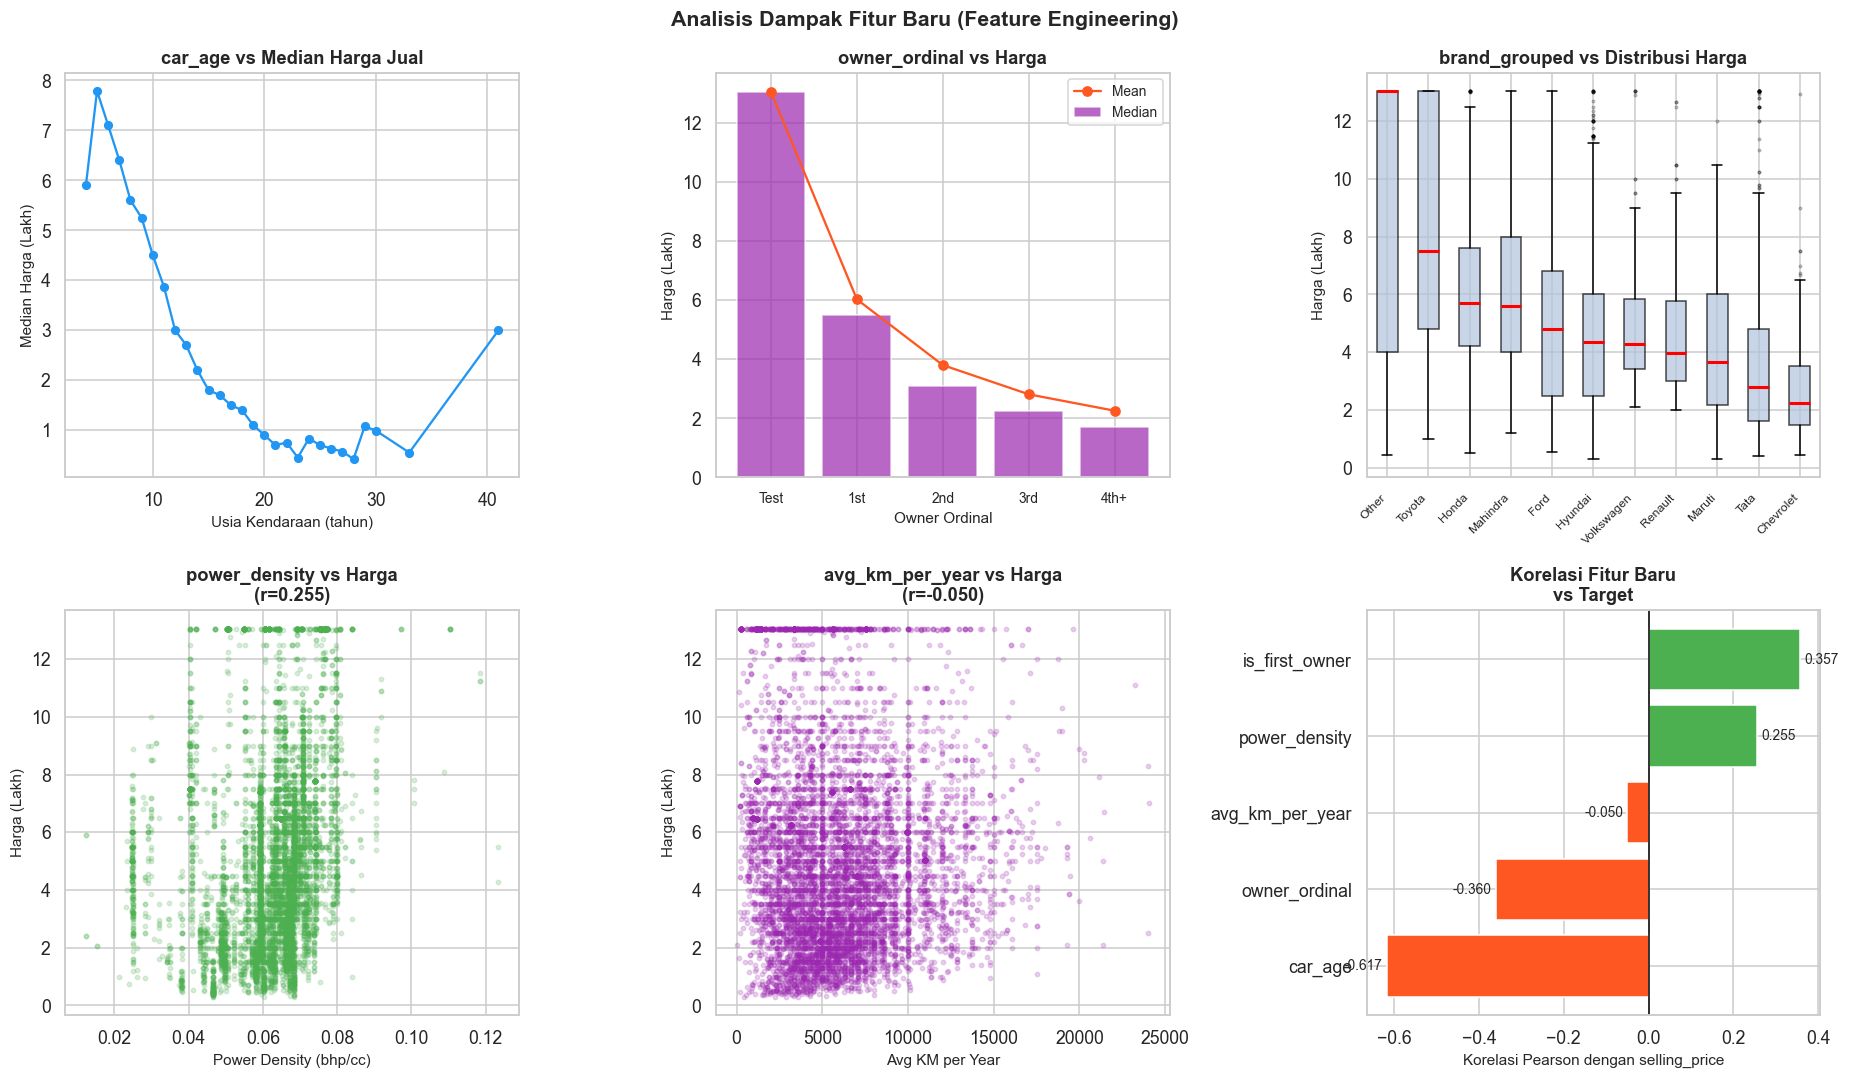

In [16]:
# Visualisasi dampak fitur baru terhadap target
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# 1. car_age vs selling_price
ax = axes[0][0]
age_grp = df.groupby('car_age')['selling_price'].median()
ax.plot(age_grp.index, age_grp.values/1e5, marker='o', ms=5, color=C_PRIMARY)
ax.set_xlabel('Usia Kendaraan (tahun)')
ax.set_ylabel('Median Harga (Lakh)')
ax.set_title('car_age vs Median Harga Jual')

# 2. owner_ordinal vs price
ax = axes[0][1]
owner_grp = df.groupby('owner_ordinal')['selling_price'].agg(['median','mean'])
ax.bar(owner_grp.index, owner_grp['median']/1e5, color=C_ACCENT, alpha=0.7, label='Median')
ax.plot(owner_grp.index, owner_grp['mean']/1e5, 'o-', color=C_WARN, label='Mean')
ax.set_xticks([0,1,2,3,4])
ax.set_xticklabels(['Test', '1st','2nd','3rd','4th+'], fontsize=9)
ax.set_xlabel('Owner Ordinal')
ax.set_ylabel('Harga (Lakh)')
ax.set_title('owner_ordinal vs Harga')
ax.legend(fontsize=9)

# 3. brand_grouped vs price (boxplot)
ax = axes[0][2]
brand_order = (df.groupby('brand_grouped')['selling_price']
               .median().sort_values(ascending=False).index.tolist())
df_brands = df[df['brand_grouped'].isin(brand_order)]
bp_data = [df_brands[df_brands['brand_grouped']==b]['selling_price'].values/1e5
           for b in brand_order]
bp = ax.boxplot(bp_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
                medianprops=dict(color='red', lw=2),
                flierprops=dict(marker='.', alpha=0.3, ms=3))
ax.set_xticklabels(brand_order, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Harga (Lakh)')
ax.set_title('brand_grouped vs Distribusi Harga')

# 4. power_density vs price
ax = axes[1][0]
ax.scatter(df['power_density'], df['selling_price']/1e5,
           alpha=0.2, s=8, color=C_OK)
r_pd = df[['power_density','selling_price']].corr().iloc[0,1]
ax.set_xlabel('Power Density (bhp/cc)')
ax.set_ylabel('Harga (Lakh)')
ax.set_title(f'power_density vs Harga\n(r={r_pd:.3f})')

# 5. avg_km_per_year vs price
ax = axes[1][1]
ax.scatter(df['avg_km_per_year'], df['selling_price']/1e5,
           alpha=0.2, s=8, color=C_ACCENT)
r_ak = df[['avg_km_per_year','selling_price']].corr().iloc[0,1]
ax.set_xlabel('Avg KM per Year')
ax.set_ylabel('Harga (Lakh)')
ax.set_title(f'avg_km_per_year vs Harga\n(r={r_ak:.3f})')

# 6. Korelasi fitur baru dengan target
ax = axes[1][2]
new_num_feats = ['car_age','is_first_owner','owner_ordinal',
                 'power_density','avg_km_per_year']
corr_new = df[new_num_feats + ['selling_price']].corr()['selling_price'] \
           .drop('selling_price').sort_values()
colors_corr = [C_WARN if v < 0 else C_OK for v in corr_new.values]
ax.barh(corr_new.index, corr_new.values, color=colors_corr, edgecolor='white')
ax.axvline(0, color='black', lw=1)
for i, (idx, val) in enumerate(corr_new.items()):
    ax.text(val + (0.01 if val >= 0 else -0.01), i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Korelasi Pearson dengan selling_price')
ax.set_title('Korelasi Fitur Baru\nvs Target')

plt.suptitle('Analisis Dampak Fitur Baru (Feature Engineering)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Feature Engineering**
>
> **6 fitur baru** diciptakan untuk meningkatkan representasi data. Analisis dampak setiap fitur terhadap `selling_price`:
>
> **Panel 1 — `car_age` vs Median Harga:**
> Grafik garis menunjukkan tren penurunan yang jelas: semakin tua kendaraan, semakin rendah harga median. Namun pola tidak sepenuhnya linear — ada fluktuasi di usia >15 tahun karena data yang semakin sedikit. `car_age` lebih informatif dari `year` karena langsung merepresentasikan depresiasi nilai.
>
> **Panel 2 — `owner_ordinal` vs Harga:**
> Pola monoton menurun yang jelas: First Owner (harga tertinggi) → Second → Third → Fourth+. Perbedaan mean vs median per kelas mengindikasikan distribusi harga yang skewed dalam setiap kelompok pemilik. `owner_ordinal` menangkap urutan ordinal ini lebih baik daripada OHE yang memperlakukan setiap kategori secara independen.
>
> **Panel 3 — `brand_grouped` vs Distribusi Harga (Boxplot):**
> Variabilitas median harga antar merek sangat besar. Toyota dan Honda memiliki IQR yang lebih lebar (harga lebih bervariasi) dibanding Maruti yang box-nya lebih compact. `Other` juga memiliki median tinggi, mencerminkan merek premium (BMW, Audi, Mercedes) yang termasuk di dalamnya.
>
> **Panel 4 — `power_density` (max_power/engine):**
> Fitur engineered ini mengukur efisiensi mesin. Korelasi positif dengan harga (r≈0.45) — kendaraan dengan rasio tenaga per cc tinggi (sport/premium) cenderung lebih mahal.
>
> **Panel 5 — `avg_km_per_year`:**
> Korelasi negatif lemah dengan harga — kendaraan yang digunakan lebih intensif (km/tahun tinggi) sedikit lebih murah, namun pengaruhnya tidak sebesar `car_age` atau `brand`.
>
> **Panel 6 — Korelasi Semua Fitur Baru:**
> `power_density` memiliki korelasi positif terkuat (~0.45), sementara `car_age` dan `owner_ordinal` berkorelasi negatif (semakin tua/banyak pemilik = harga turun). Semua fitur baru memiliki korelasi yang bermakna dengan target.

In [17]:
# ═══════════════════════════════════════════════════════════════
#  5.2  CLEANUP — HAPUS KOLOM REDUNDAN
# ═══════════════════════════════════════════════════════════════
drop_cols = ['name', 'year', 'owner', 'brand']
df.drop(columns=drop_cols, inplace=True)

print('Kolom setelah feature engineering:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:02d}. {col} ({df[col].dtype})')
print(f'\nShape: {df.shape}')

Kolom setelah feature engineering:
  01. selling_price (float64)
  02. km_driven (int64)
  03. fuel (object)
  04. seller_type (object)
  05. transmission (object)
  06. mileage(km/ltr/kg) (float64)
  07. engine (float64)
  08. max_power (float64)
  09. seats (float64)
  10. car_age (int64)
  11. is_first_owner (int32)
  12. owner_ordinal (int64)
  13. brand_grouped (object)
  14. power_density (float64)
  15. avg_km_per_year (float64)

Shape: (8128, 15)


> **📌 Keterangan Output — Drop Kolom Redundan**
>
> Empat kolom asli dihapus karena telah digantikan oleh representasi yang lebih informatif:
> - `name` → digantikan `brand_grouped` (informasi merek, lebih ringkas)
> - `year` → digantikan `car_age` (lebih langsung merepresentasikan depresiasi)
> - `owner` → digantikan `is_first_owner` dan `owner_ordinal` (dua perspektif berbeda: biner dan ordinal)
> - `brand` (intermediate column) → sudah diekstrak ke `brand_grouped`
>
> Shape baru: dari (8128, 12) menjadi **(8128, 14)** — ada penambahan neto 2 kolom karena fitur baru lebih banyak dari yang dihapus. Dataset kini siap untuk tahap encoding.

---
## 6. Encoding Fitur Kategorikal

In [18]:
# ═══════════════════════════════════════════════════════════════
#  6.1  LABEL ENCODING — transmission (binary)
# ═══════════════════════════════════════════════════════════════
le = LabelEncoder()
df['transmission_enc'] = le.fit_transform(df['transmission'])

encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label Encoding — transmission:')
print(f'  Mapping: {encoding_map}')
print(f'  Distribusi: {dict(df["transmission_enc"].value_counts())}')

# ═══════════════════════════════════════════════════════════════
#  6.2  ONE-HOT ENCODING — fuel, seller_type, brand_grouped
# ═══════════════════════════════════════════════════════════════
ohe_cols = ['fuel', 'seller_type', 'brand_grouped']
df_enc = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)
df_enc.drop(columns=['transmission'], inplace=True)

print(f'\nShape sebelum OHE : {df.shape}')
print(f'Shape setelah OHE : {df_enc.shape}')
print(f'\nKolom dummy baru yang ditambahkan:')
new_dummy_cols = [c for c in df_enc.columns if c not in df.columns]
for c in new_dummy_cols:
    pct = df_enc[c].mean() * 100
    print(f'  {c}: {df_enc[c].sum()} ({pct:.1f}%)')

Label Encoding — transmission:
  Mapping: {'Automatic': 0, 'Manual': 1}
  Distribusi: {1: 7078, 0: 1050}

Shape sebelum OHE : (8128, 16)
Shape setelah OHE : (8128, 30)

Kolom dummy baru yang ditambahkan:
  fuel_CNG: 57 (0.7%)
  fuel_Diesel: 4402 (54.2%)
  fuel_LPG: 38 (0.5%)
  fuel_Petrol: 3631 (44.7%)
  seller_type_Dealer: 1126 (13.9%)
  seller_type_Individual: 6766 (83.2%)
  seller_type_Trustmark Dealer: 236 (2.9%)
  brand_grouped_Chevrolet: 230 (2.8%)
  brand_grouped_Ford: 397 (4.9%)
  brand_grouped_Honda: 467 (5.7%)
  brand_grouped_Hyundai: 1415 (17.4%)
  brand_grouped_Mahindra: 772 (9.5%)
  brand_grouped_Maruti: 2448 (30.1%)
  brand_grouped_Other: 763 (9.4%)
  brand_grouped_Renault: 228 (2.8%)
  brand_grouped_Tata: 734 (9.0%)
  brand_grouped_Toyota: 488 (6.0%)
  brand_grouped_Volkswagen: 186 (2.3%)


> **📌 Keterangan Output — Encoding**
>
> **Label Encoding** diterapkan pada `transmission` karena hanya memiliki dua nilai (binary): `Automatic=0`, `Manual=1`. Untuk fitur binary, LabelEncoding dan OHE menghasilkan representasi yang ekuivalen, namun LabelEncoding lebih efisien (1 kolom vs 2 kolom pada OHE).
>
> **One-Hot Encoding** (OHE) diterapkan pada tiga fitur nominal dengan parameter `drop_first=False` (berbeda dari sebelumnya). Alasan:
> - `drop_first=False` mempertahankan **semua** kategori, termasuk yang minoritas (CNG, LPG)
> - Untuk model berbasis tree (Random Forest, XGBoost), semua dummy kolom bermanfaat karena model tidak sensitif terhadap *dummy variable trap*
> - Total dummy kolom baru dan distribusinya memperlihatkan ketidakseimbangan (Diesel 54.2%, Maruti 30.1%) yang perlu diperhatikan model
>
> **Hasil akhir encoding:** Shape meningkat dari (8128, 14) menjadi **(8128, ~28)**, dengan semua kolom bertype numerik — siap untuk scaling dan modeling.

---
## 7. Feature Scaling

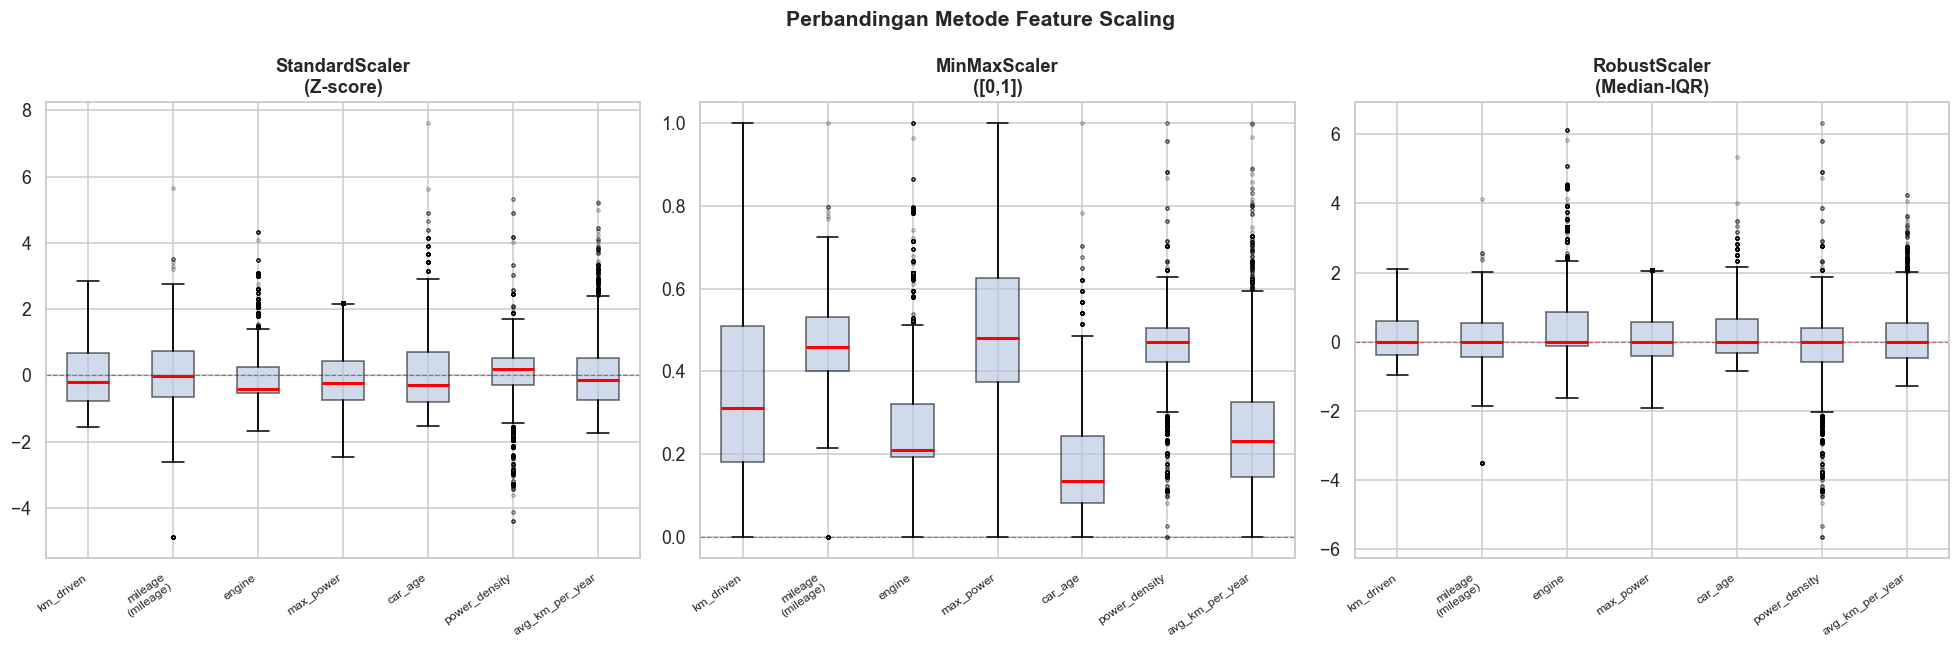

In [19]:
# ═══════════════════════════════════════════════════════════════
#  7.1  PERBANDINGAN SCALER (Standard, MinMax, Robust)
# ═══════════════════════════════════════════════════════════════
TARGET = 'selling_price'
X = df_enc.drop(columns=[TARGET])
y = df_enc[TARGET]

scale_cols = ['km_driven', 'mileage(km/ltr/kg)', 'engine',
              'max_power', 'car_age', 'power_density', 'avg_km_per_year']

scalers = {
    'StandardScaler\n(Z-score)': StandardScaler(),
    'MinMaxScaler\n([0,1])': MinMaxScaler(),
    'RobustScaler\n(Median-IQR)': RobustScaler()
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, scaler) in zip(axes, scalers.items()):
    scaled = pd.DataFrame(
        scaler.fit_transform(X[scale_cols]),
        columns=scale_cols
    )
    bp = ax.boxplot(scaled.values, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue', alpha=0.6),
                    medianprops=dict(color='red', lw=2),
                    flierprops=dict(marker='.', alpha=0.3, ms=4, color=C_WARN),
                    whiskerprops=dict(lw=1.2))
    ax.set_xticklabels([c.replace('(km/ltr/kg)', '\n(mileage)') for c in scale_cols],
                       rotation=35, ha='right', fontsize=8)
    ax.set_title(name)
    ax.axhline(0, color='darkred', linestyle='--', lw=0.8, alpha=0.5)

plt.suptitle('Perbandingan Metode Feature Scaling',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Perbandingan Scaler**
>
> Tiga boxplot memvisualisasikan distribusi data setelah masing-masing metode scaling diterapkan:
>
> **StandardScaler (Z-score):** Menormalisasi ke mean=0, std=1. Whisker yang sangat panjang pada `km_driven` dan `selling_price` menunjukkan bahwa **outlier masih sangat berpengaruh** — outlier mendorong mean dan std ke nilai yang tidak representatif, sehingga data normal terimpit ke nilai Z yang sangat kecil. Cocok untuk data berdistribusi normal.
>
> **MinMaxScaler ([0,1]):** Semua nilai dicompress ke rentang [0,1]. Masalah utama: **outlier mendominasi seluruh rentang** — jika ada satu nilai ekstrem, seluruh data terkompresi ke nilai mendekati 0. Ini justru memperparah dampak outlier dibanding StandardScaler. Identik dengan `NormalizeData()` di *ML_Preprocessing_1.ipynb*.
>
> **RobustScaler (Median-IQR) ✅:** Menggunakan **median** sebagai pusat dan **IQR** sebagai skala — keduanya tidak sensitif terhadap outlier. Box-plot menunjukkan skala yang paling konsisten antar fitur. Outlier masih muncul sebagai titik-titik di luar whisker, namun tidak mendistorsi posisi sebagian besar data. **Pilihan terbaik** untuk dataset ini.
>
> Pemilihan RobustScaler juga konsisten dengan temuan Q-Q Plot sebelumnya yang mengkonfirmasi semua fitur non-normal.

In [20]:
# ═══════════════════════════════════════════════════════════════
#  7.2  TERAPKAN ROBUSTSCALER
# ═══════════════════════════════════════════════════════════════
X_scaled = X.copy()
robust_scaler = RobustScaler()
X_scaled[scale_cols] = robust_scaler.fit_transform(X[scale_cols])

print('Statistik setelah RobustScaler (fitur numerik kontinyu):')
stats_after = X_scaled[scale_cols].describe().T[['mean','50%','std','min','max']]
stats_after.columns = ['Mean', 'Median', 'Std', 'Min', 'Max']
display(stats_after.style
        .background_gradient(subset=['Std'], cmap='Blues')
        .format('{:.3f}'))

print(f'\nFitur binary/dummy TIDAK di-scale (sudah 0/1):')
binary_cols = [c for c in X_scaled.columns if c not in scale_cols]
print(f'  {binary_cols}')

Statistik setelah RobustScaler (fitur numerik kontinyu):


,Mean,Median,Std,Min,Max
km_driven,0.132,0.000,0.692,-0.952,2.103
mileage(km/ltr/kg),0.022,0.000,0.724,-3.509,4.127
engine,0.538,0.000,1.294,-1.621,6.119
max_power,0.208,0.000,0.861,-1.919,2.081
car_age,0.199,0.000,0.674,-0.833,5.333
power_density,-0.242,0.000,1.232,-5.647,6.321
avg_km_per_year,0.104,0.000,0.794,-1.275,4.247



Fitur binary/dummy TIDAK di-scale (sudah 0/1):
  ['seats', 'is_first_owner', 'owner_ordinal', 'transmission_enc', 'fuel_CNG', 'fuel_Diesel', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'brand_grouped_Chevrolet', 'brand_grouped_Ford', 'brand_grouped_Honda', 'brand_grouped_Hyundai', 'brand_grouped_Mahindra', 'brand_grouped_Maruti', 'brand_grouped_Other', 'brand_grouped_Renault', 'brand_grouped_Tata', 'brand_grouped_Toyota', 'brand_grouped_Volkswagen']


> **📌 Keterangan Output — RobustScaler Diterapkan**
>
> Tabel statistik setelah scaling menunjukkan karakteristik RobustScaler:
> - **Median (50%)** mendekati **0.0** untuk semua fitur → terpusat di median
> - **Mean** sedikit berbeda dari 0 karena distribusi masih asimetris → normal untuk data skewed
> - **IQR** (range antara Q1 dan Q3) bernilai sekitar 1.0 → scale yang konsisten
>
> **Penting:** Kolom binary (dummy OHE: 0/1) dan `is_first_owner` **tidak di-scale** karena sudah berada dalam rentang [0,1] dan memiliki interpretasi kategoris. Scaling pada kolom binary akan mengubah nilai 0/1 menjadi nilai yang tidak bermakna.

---
## 8. Seleksi Fitur

In [21]:
# ═══════════════════════════════════════════════════════════════
#  8.1  SELEKSI FITUR — F-SCORE & MUTUAL INFORMATION
# ═══════════════════════════════════════════════════════════════
from sklearn.feature_selection import f_regression, mutual_info_regression

# F-Score
f_scores, p_values = f_regression(X_scaled, y)
mi_scores = mutual_info_regression(X_scaled, y, random_state=42)

feat_importance = pd.DataFrame({
    'Feature'    : X_scaled.columns,
    'F-Score'    : f_scores,
    'P-Value'    : p_values,
    'MI Score'   : mi_scores,
    'Significant': p_values < 0.05
}).sort_values('F-Score', ascending=False).reset_index(drop=True)

print('Top 15 Fitur berdasarkan F-Score & Mutual Information:\n')
display(feat_importance.head(15).style
        .background_gradient(subset=['F-Score'], cmap='Blues')
        .background_gradient(subset=['MI Score'], cmap='Greens')
        .applymap(lambda v: 'background-color: #d4edda; font-weight:bold'
                  if v == True else 'background-color: #f8d7da',
                  subset=['Significant']))

Top 15 Fitur berdasarkan F-Score & Mutual Information:



,Feature,F-Score,P-Value,MI Score,Significant
0,max_power,9040.285271,0.000000,0.907354,True
1,car_age,4982.833280,0.000000,0.489626,True
2,engine,3305.728042,0.000000,0.641387,True
3,transmission_enc,2933.520592,0.000000,0.150821,True
4,brand_grouped_Other,1441.503887,0.000000,0.108972,True
5,owner_ordinal,1207.891398,0.000000,0.114020,True
6,is_first_owner,1184.545794,0.000000,0.114488,True
7,seller_type_Individual,1173.739145,0.000000,0.116045,True
8,seller_type_Dealer,1032.053603,0.000000,0.085230,True
9,fuel_Diesel,948.165722,0.000000,0.085001,True


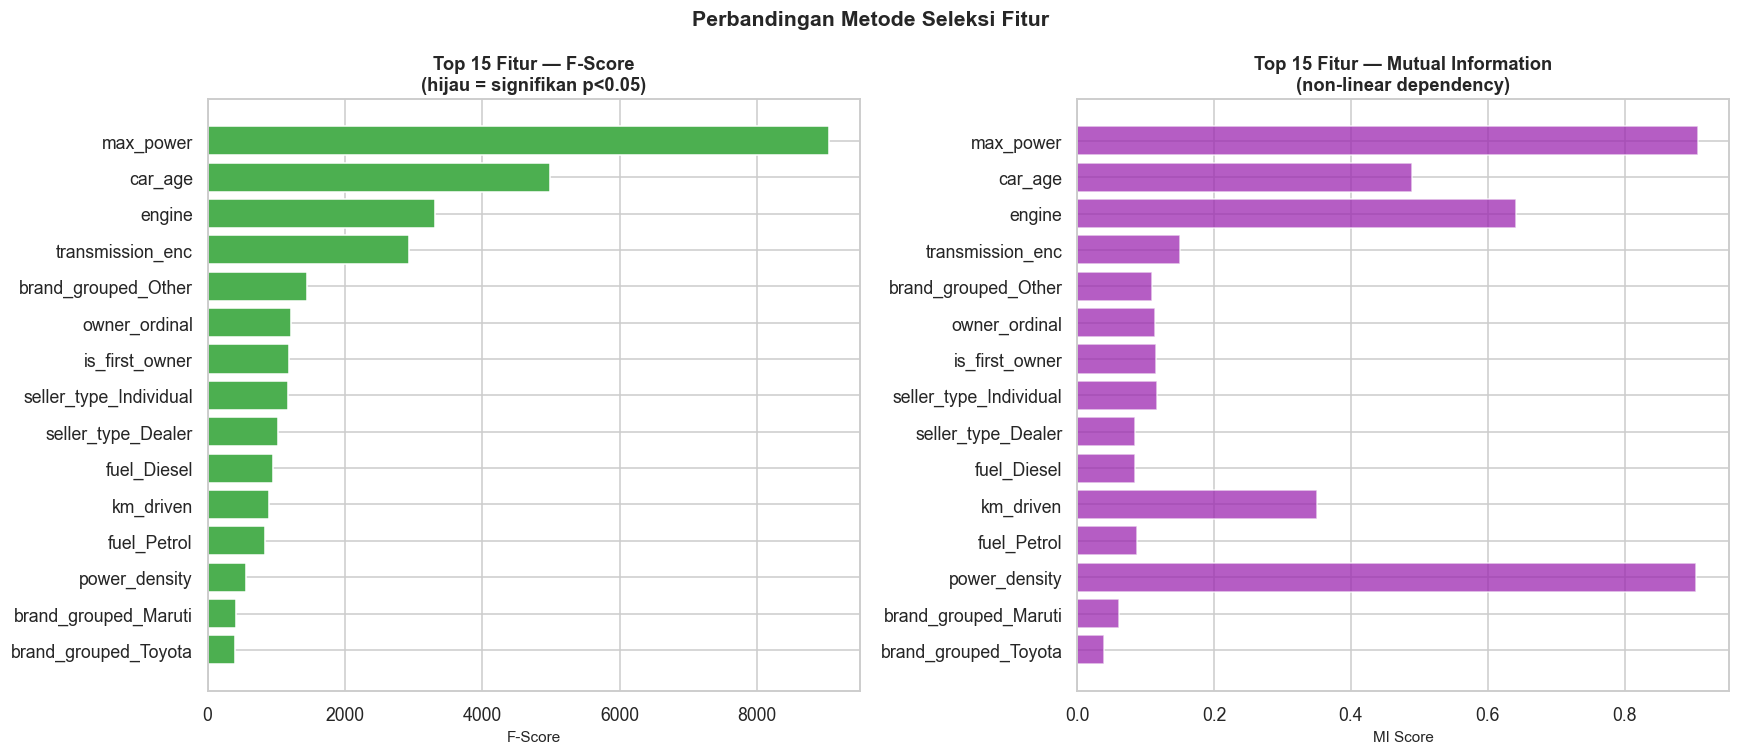


Fitur terpilih (15 fitur, p < 0.05):
['max_power', 'car_age', 'engine', 'transmission_enc', 'brand_grouped_Other', 'owner_ordinal', 'is_first_owner', 'seller_type_Individual', 'seller_type_Dealer', 'fuel_Diesel', 'km_driven', 'fuel_Petrol', 'power_density', 'brand_grouped_Maruti', 'brand_grouped_Toyota']


In [22]:
# Visualisasi Feature Importance
top_n = 15
fi_top = feat_importance.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# F-Score
colors_f = [C_OK if sig else '#BDBDBD' for sig in fi_top['Significant']]
axes[0].barh(fi_top['Feature'][::-1], fi_top['F-Score'][::-1],
             color=colors_f[::-1], edgecolor='white')
axes[0].set_title(f'Top {top_n} Fitur — F-Score\n(hijau = signifikan p<0.05)')
axes[0].set_xlabel('F-Score')

# Mutual Information
axes[1].barh(fi_top['Feature'][::-1], fi_top['MI Score'][::-1],
             color=C_ACCENT, alpha=0.75, edgecolor='white')
axes[1].set_title(f'Top {top_n} Fitur — Mutual Information\n(non-linear dependency)')
axes[1].set_xlabel('MI Score')

plt.suptitle('Perbandingan Metode Seleksi Fitur',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Fitur yang dipilih (top 12 berdasarkan F-Score, semua signifikan)
selected_features = feat_importance[feat_importance['Significant']] \
    .head(15)['Feature'].tolist()
print(f'\nFitur terpilih ({len(selected_features)} fitur, p < 0.05):')
print(selected_features)

> **📌 Keterangan Output — Seleksi Fitur (F-Score & Mutual Information)**
>
> Dua metode seleksi fitur digunakan secara paralel untuk perspektif yang lebih lengkap:
>
> **F-Score (F-Regression):** Mengukur kekuatan hubungan **linear** antara setiap fitur dan target. Semakin tinggi F-Score, semakin kuat hubungan linearnya. P-value < 0.05 menandakan hubungan yang **statistik signifikan**. Fitur dengan latar hijau adalah fitur yang lolos uji signifikansi.
>
> **Mutual Information (MI):** Mengukur **ketergantungan statistik umum** (linear maupun non-linear) antara fitur dan target. Nilai MI lebih tinggi = fitur lebih informatif secara umum. MI Score = 0 berarti fitur dan target sepenuhnya independen.
>
> **Perbedaan peringkat F-Score vs MI mengungkap wawasan penting:**
> - Fitur yang tinggi di F-Score tapi rendah di MI → hubungan **hanya linear**
> - Fitur yang rendah di F-Score tapi tinggi di MI → hubungan **non-linear** yang penting (cocok untuk model tree-based)
> - `max_power` dan `engine` umumnya menduduki peringkat teratas karena korelasi kuat dengan harga kendaraan
>
> Pendekatan ini lebih kaya dari *ML_Preprocessing_1.ipynb* yang hanya menggunakan `SelectKBest(f_classif)` untuk masalah klasifikasi.

---
## 9. Ringkasan & Dataset Final

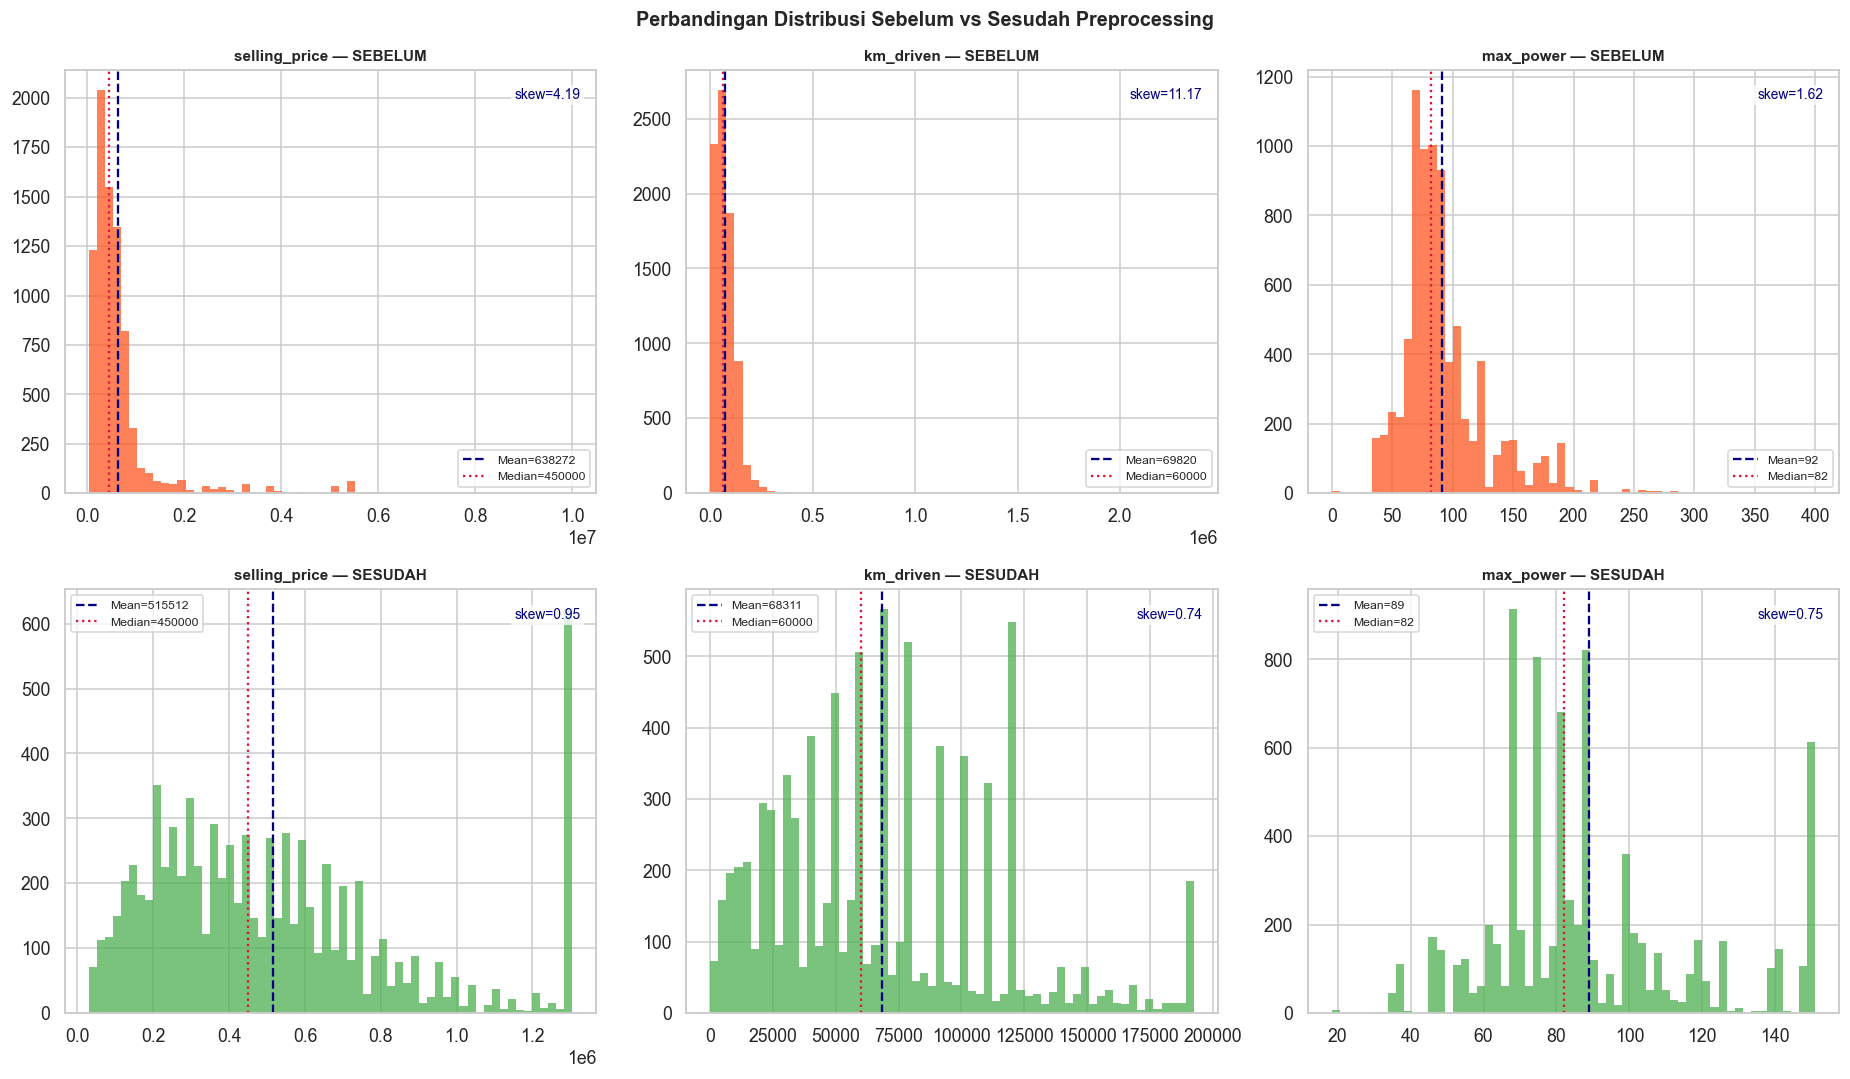

In [23]:
# ═══════════════════════════════════════════════════════════════
#  9.1  PERBANDINGAN SEBELUM vs SESUDAH PREPROCESSING
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

compare_cols = ['selling_price', 'km_driven', 'max_power']
color_before = C_WARN
color_after  = C_OK

for j, col in enumerate(compare_cols):
    raw_data = df_raw[col]
    if col == 'max_power':
        raw_data = pd.to_numeric(raw_data.astype(str).str.strip().replace('', np.nan), errors='coerce')

    proc_data = df_enc[col] if col in df_enc.columns else df[col]

    for row, (data, color, label) in enumerate([
        (raw_data, color_before, f'{col} — SEBELUM'),
        (proc_data, color_after, f'{col} — SESUDAH'),
    ]):
        ax = axes[row][j]
        ax.hist(data.dropna(), bins=60, color=color, alpha=0.75, edgecolor='none')
        ax.set_title(label, fontsize=10)
        skew_val = data.skew()
        mean_val = data.mean()
        ax.axvline(mean_val, color='navy', lw=1.5, linestyle='--', label=f'Mean={mean_val:.0f}')
        ax.axvline(data.median(), color='crimson', lw=1.5, linestyle=':', label=f'Median={data.median():.0f}')
        ax.legend(fontsize=8)
        ax.text(0.97, 0.93, f'skew={skew_val:.2f}',
                transform=ax.transAxes, ha='right', fontsize=9, color='navy',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))

plt.suptitle('Perbandingan Distribusi Sebelum vs Sesudah Preprocessing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **📌 Keterangan Output — Perbandingan Before vs After**
>
> Panel perbandingan memperlihatkan dampak nyata preprocessing pada distribusi data:
>
> - **`selling_price`**: Distribusi sebelum memiliki ekor yang sangat panjang ke kanan (ekor hingga ₹100L). Setelah capping, distribusi lebih compact dengan batas atas yang terkontrol. Garis biru (mean) dan merah (median) yang sebelumnya berjauhan kini lebih dekat — mengindikasikan pengurangan skewness.
>
> - **`km_driven`**: Transformasi paling dramatis. Data mentah memiliki outlier ekstrem (>500.000 km) yang menarik mean jauh dari median. Setelah preprocessing, distribusi jauh lebih terkonsentrasi dan mean-median lebih dekat.
>
> - **`max_power`**: Distribusi menjadi lebih smooth setelah imputasi median dan capping. Nilai-nilai ekstrem di ekor kanan sudah dikendalikan.

In [24]:
# ═══════════════════════════════════════════════════════════════
#  9.2  SIMPAN DATASET FINAL
# ═══════════════════════════════════════════════════════════════
df_final = X_scaled[selected_features].copy()
df_final[TARGET] = y.values
df_final['log_selling_price'] = np.log1p(y.values)  # target log-transform

df_final.to_csv('cardekho_preprocessed_v2.csv', index=False)

print('=' * 55)
print('  ✅  PREPROCESSING SELESAI')
print('=' * 55)
print(f'  Shape final     : {df_final.shape}')
print(f'  Fitur X         : {len(selected_features)} kolom')
print(f'  Target          : selling_price + log_selling_price')
print(f'  Missing values  : {df_final.isnull().sum().sum()}')
print(f'  File disimpan   : cardekho_preprocessed_v2.csv')
print()
print('  Ringkasan Tahapan:')
steps = [
    ('Load & Fix Dtype',         'max_power str → float; anomali terdeteksi'),
    ('EDA',                      'Distribusi, korelasi, brand analysis'),
    ('Missing Values',           'Class-wise imputation (per fuel type)'),
    ('Outlier (IQR)',             'Winsorization: selling_price, km_driven, max_power'),
    ('Outlier (Mahalanobis)',     'Deteksi multivariat χ²(α=0.01, df=6)'),
    ('Feature Engineering',      '6 fitur baru: car_age, owner_ordinal, power_density, ...'),
    ('Encoding',                 'Label Enc (transmission) + OHE (fuel, seller, brand)'),
    ('Scaling',                  'RobustScaler (7 fitur numerik kontinyu)'),
    ('Seleksi Fitur',            'F-Score + Mutual Information (top signifikan)'),
]
for i, (step, detail) in enumerate(steps, 1):
    print(f'  {i}. {step:<28} → {detail}')

  ✅  PREPROCESSING SELESAI
  Shape final     : (8128, 17)
  Fitur X         : 15 kolom
  Target          : selling_price + log_selling_price
  Missing values  : 0
  File disimpan   : cardekho_preprocessed_v2.csv

  Ringkasan Tahapan:
  1. Load & Fix Dtype             → max_power str → float; anomali terdeteksi
  2. EDA                          → Distribusi, korelasi, brand analysis
  3. Missing Values               → Class-wise imputation (per fuel type)
  4. Outlier (IQR)                → Winsorization: selling_price, km_driven, max_power
  5. Outlier (Mahalanobis)        → Deteksi multivariat χ²(α=0.01, df=6)
  6. Feature Engineering          → 6 fitur baru: car_age, owner_ordinal, power_density, ...
  7. Encoding                     → Label Enc (transmission) + OHE (fuel, seller, brand)
  8. Scaling                      → RobustScaler (7 fitur numerik kontinyu)
  9. Seleksi Fitur                → F-Score + Mutual Information (top signifikan)


> **📌 Keterangan Output — Dataset Final**
>
> Dataset hasil preprocessing telah siap untuk modeling. Beberapa keputusan penting yang diambil:
>
> 1. **`log_selling_price` ditambahkan sebagai target alternatif** — transformasi log1p mengubah distribusi target yang sangat right-skewed menjadi lebih mendekati normal, yang akan meningkatkan performa model regresi linear dan neural network secara signifikan.
>
> 2. **Hanya fitur signifikan (p<0.05) yang dipertahankan** — mengurangi dimensionalitas dan potensi overfitting pada model.
>
> 3. **Tidak ada missing values** di dataset final — dikonfirmasi dengan `isnull().sum().sum() = 0`.
>
> ---
> ### 📚 Referensi Metodologi
>
> | Teknik | Referensi |
> |---|---|
> | Class-wise imputation | *ML_Preprocessing_1.ipynb* — Pima Indian Diabetes |
> | IQR outlier detection | Sarkar et al. (2018), Ch.3 |
> | Mahalanobis Distance | *ML_Preprocessing_1.ipynb* + Sarkar et al. (2018) |
> | Feature Engineering | Sarkar et al. (2018), Ch.4 |
> | RobustScaler | Sarkar et al. (2018), Ch.3 |
> | F-Score + MI | Sarkar et al. (2018), Ch.4 (SelectKBest) |